# Coarse-graining nonequilibrium diffusions

R. Nartallo-Kaluarachchi

This notebook supports the analysis in the paper ....

In [11]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from scipy.linalg import expm
from scipy.stats import multivariate_normal
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import lsmr, lsqr, spsolve, eigsh
from scipy.special import erf, iv
from mpl_toolkits.axes_grid1 import make_axes_locatable
import helpers as h
import importlib
from matplotlib.colors import LogNorm
import pandas as pd
from scipy.linalg import expm, norm
from scipy.optimize import minimize
from tqdm import tqdm
sns.set_theme(
    font='Times New Roman',
    palette='magma',
    rc={'font.family': 'Times New Roman'},
    style = 'white',
    font_scale = 1.5
)

In [2]:
importlib.reload(h)

<module 'helpers' from '/Users/ramon/Desktop/Year 3/Coarse Graining/helpers.py'>

### Nonequilibrium steady-states in the Ornstein-Uhlenbeck (OU) process

We begin with the OU process of the form
$$
d\begin{pmatrix}
        x(t)\\
        y(t)
    \end{pmatrix} = -\begin{pmatrix}
        2 & -\theta\\
        \theta & 2
    \end{pmatrix}\begin{pmatrix}
        x\\
        y
    \end{pmatrix}\;dt + \begin{pmatrix}
        \sigma & 0\\
        0 & \sigma
    \end{pmatrix}dW(t),
$$

which has a mean-zero Gaussian distribution with covariance $S= \frac{\sigma^2}{4}I$ and $\Phi = \theta^2$.

First we show that the stationary distribution of the OU process is conserved in the coarse-grained Markov process

We define the process,

In [3]:
def drift_matrix(theta,sigma): return -np.array([[2, -theta],[theta, 2]])
def diffusion_matrix(theta,sigma): return np.array([[0.5*(sigma**2), 0],[0, 0.5*(sigma**2)]])

In [4]:
theta = 5; sigma = 5

def f_x(x,y):
    z = drift_matrix(theta,sigma)@np.array([x,y])
    return z[0]

def f_y(x,y):
    z = drift_matrix(theta,sigma)@np.array([x,y])
    return z[1]

def D_xx(x,y):
    return diffusion_matrix(theta,sigma)[0,0]

def D_yy(x,y):
    return diffusion_matrix(theta,sigma)[1,1]

Next, we use the *Scharfetter-Gummel* discretisation (SGD) to construct a Markov process, where we then solve for the stationary distribution

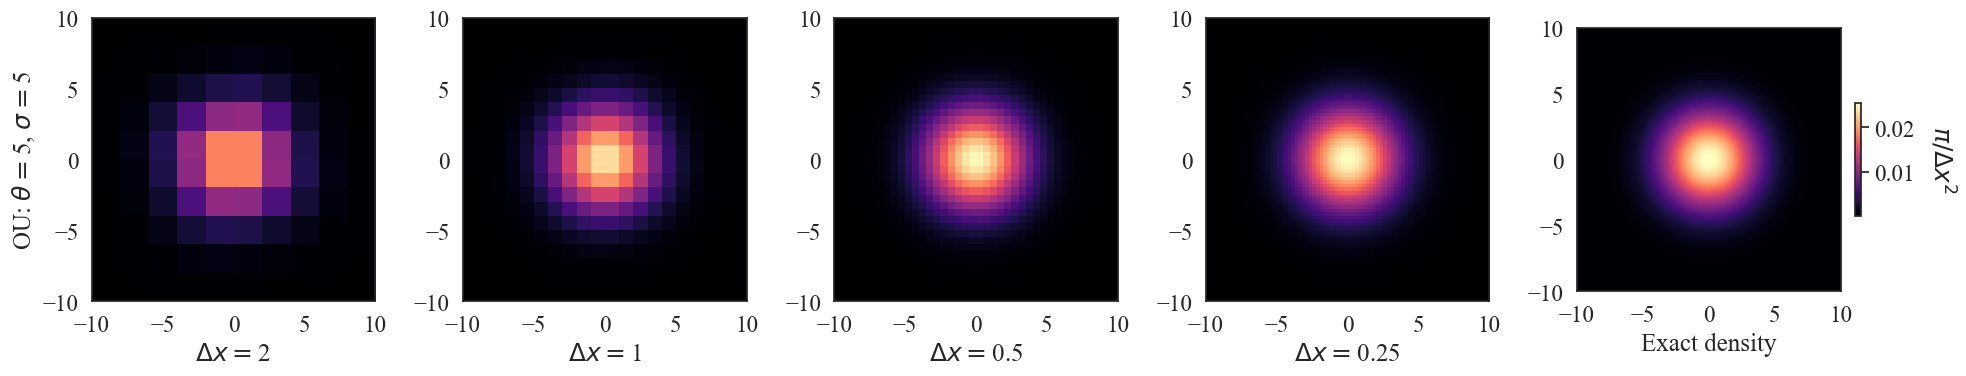

In [5]:
xmin = -10; xmax = 10;
ymin = -10; ymax = 10;
dx = 0.1; dy = 0.1;

fig, ax = plt.subplots(1, 5)
fig.set_size_inches(20, 4)
cmap = plt.get_cmap('magma')

dx_range = [2, 1, 0.5,0.25]
grid_list = []
dist_list = []

vmin = float('inf')
vmax = float('-inf')

for dx in dx_range:
    L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_reflecting_boundaries(
        [f_x, f_y], [D_xx, D_yy], dx, xmin, xmax, dx, ymin, ymax
    )
    p_ss = h.efficient_stationary_dist(L).reshape(x_midpoints.shape[0], y_midpoints.shape[0]) / (dx**2)
    grid_list.append([x_midpoints, y_midpoints])
    dist_list.append(p_ss)
    vmin = min(vmin, p_ss.min())
    vmax = max(vmax, p_ss.max())

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

for i, p_ss in enumerate(dist_list):
    im = ax[i].imshow(p_ss, extent=[xmin, xmax, ymin, ymax], 
                      origin='lower', cmap=cmap, norm=norm)
    ax[i].set_xlabel(r'$\Delta x = $' + str(dx_range[i]))
    ax[i].set_aspect('equal')
    ax[i].set_xticks([-10,-5, 0, 5,10])  
    ax[i].set_yticks([-10,-5, 0, 5,10]) 

x = np.linspace(xmin, xmax, 5001)
y = np.linspace(ymin, ymax, 5001)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
rv = multivariate_normal([0,0], 0.25*(sigma**2)*np.eye(2))
Z = rv.pdf(pos)
Z_scaled = np.sum(p_ss)*Z/np.sum(Z)
c = ax[4].contourf(X, Y, Z, levels=100, cmap=cmap,vmin=vmin,vmax=vmax)
c.set_edgecolor("face")
cbar2 = fig.colorbar(c, ax=ax[4], orientation='vertical', fraction=0.02, pad=0.05)
cbar2.set_label(r'$\pi/\Delta x^2$', rotation=270, labelpad=30)
cbar2.set_ticks([0.01,0.02])
ax[0].set_ylabel(f"OU: " + str(r'$\theta =$' + str(theta) + r', $\sigma= $' +str(sigma)))
ax[4].set_xlabel("Exact density")
ax[4].set_aspect('equal')
ax[4].set_xticks([-10,-5, 0, 5,10])  
ax[4].set_yticks([-10,-5, 0, 5,10])

#plt.savefig("OU_density.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

We then consider the EPR of the discretised process and compare it to the underlying diffusion.

In [24]:
theta_range = np.linspace(0,7.5,11)
dx_range = [2, 1, 0.5,0.25]

xmin = -10; xmax = 10;
ymin = -10; ymax = 10;

EPR_discrete = np.zeros((len(theta_range),len(dx_range)))

In [25]:
sigma = 5
for i, theta in enumerate(theta_range):
    for j, dx in enumerate(dx_range):
        def f_x(x,y):
            z = drift_matrix(theta,sigma)@np.array([x,y])
            return z[0]
        
        def f_y(x,y):
            z = drift_matrix(theta,sigma)@np.array([x,y])
            return z[1]
        
        def D_xx(x,y):
            return diffusion_matrix(theta,sigma)[0,0]
        
        def D_yy(x,y):
            return diffusion_matrix(theta,sigma)[1,1]
        L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_reflecting_boundaries(
            [f_x, f_y], [D_xx, D_yy], dx, xmin, xmax, dx, ymin, ymax
        )
        
        p_ss = h.efficient_stationary_dist(L)

        EPR_discrete[i,j] = h.EPR_MC(L,p_ss)

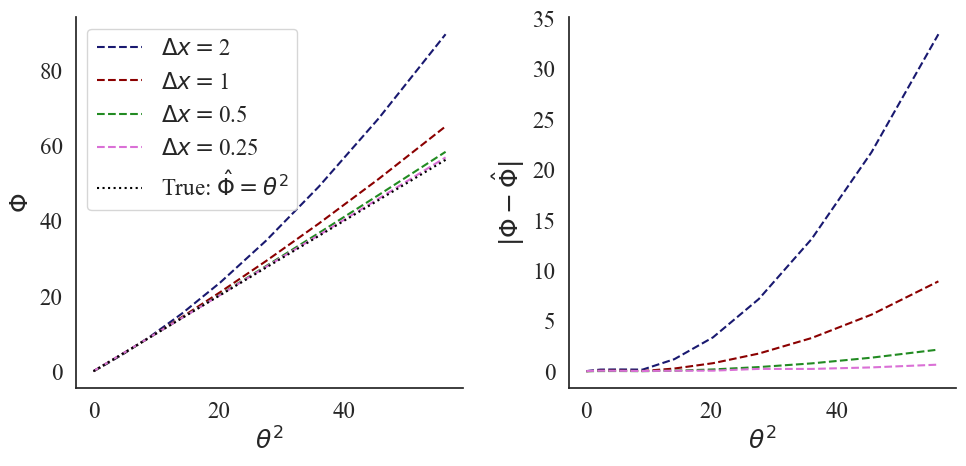

In [32]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10, 5)

EPR_true = theta_range**2

cols = ['midnightblue','darkred','forestgreen','orchid']

for i in range(0,len(dx_range)):
    ax[0].plot(theta_range**2,EPR_discrete[:,i],color=cols[i],linestyle='dashed',label = r'$\Delta x = $' + str(dx_range[i]))
    ax[1].plot(theta_range**2,np.abs(EPR_discrete[:,i] - theta_range**2),color=cols[i],linestyle='dashed',label = r'$\Delta x = $' + str(dx_range[i]))
ax[0].plot(theta_range**2,EPR_true,color='black',linestyle='dotted',label = r'True: $\hat{\Phi} = \theta^2$',alpha = 1)

ax[0].set_xlabel(r'$\omega^2$')
ax[1].set_xlabel(r'$\omega^2$')

ax[0].set_ylabel(r'$\Phi$')
ax[1].set_ylabel(r'$|\Phi - \hat{\Phi}|$')

ax[0].legend()
sns.despine()
plt.tight_layout()
plt.show()

### The Hopf oscillator

We now consider the stochastic Hopf oscillator given by

$$
    dx(t)= (a-x^2-y^2)x-\omega y\; dt+ \sigma dW_x(t),
$$
$$
    dy(t)= (a-x^2-y^2)y+\omega x\; dt+ \sigma dW_y(t).
$$

First, we investigate the shape and behaviour of the Hopf oscillator as a function of its frequency and bifurcation parameter.

In [13]:
def hopf_stationary_dist(x,y,a,sigma):
    return np.exp(((x**2+y**2)/(sigma**2))*(a-0.5*(x**2+y**2)))

a = 1; sigma = 0.5

normalising, _ = sp.integrate.quad(lambda x: sp.integrate.quad(hopf_stationary_dist, -np.inf, np.inf, args=(x,a,sigma))[0], -np.inf, np.inf)

def hopf_stationary_density(x,y,a,sigma):
    return hopf_stationary_dist(x,y,a,sigma)/normalising

x = np.linspace(-2, 2, 101)
y = np.linspace(-2, 2, 101)
X, Y = np.meshgrid(x, y)
x_c = np.linspace(-2, 2, 11)
y_c = np.linspace(-2, 2, 11)
X_c, Y_c = np.meshgrid(x_c, y_c)

Z = hopf_stationary_density(X,Y,a,sigma)

omega = 2

ju = -omega*Y*Z 
jv = omega*X*Z

def Hopf_EPR(a, sigma, omega, normalising=None):
    if normalising is None:
        Z = (1/np.sqrt(2)) * np.pi**(3/2) * sigma * np.exp((a**2)/(2*sigma**2)) * (1 + erf(a / (np.sqrt(2) * sigma)))
    else:
        Z = normalising
    term1 = (np.pi * omega**2) / (sigma * Z)
    term2 = (2 * sigma + (np.sqrt(2 * np.pi) * a * np.exp((a**2)/(2*sigma**2)))*(1 + erf(a / (np.sqrt(2) * sigma))))
    
    Phi = term1 * term2
    return Phi

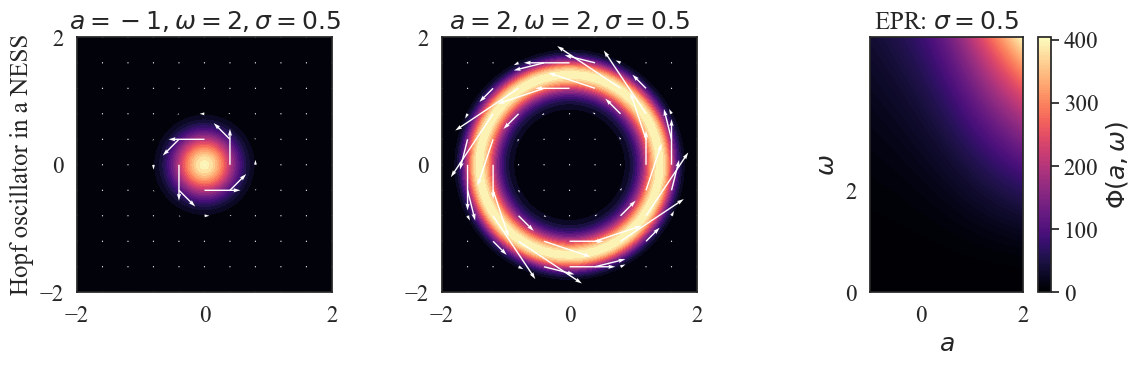

In [3]:
fig, ax = plt.subplots(1,3)
fig.set_size_inches(12,4)
Z = hopf_stationary_density(X,Y,a=-1,sigma=0.5)
Z_c = hopf_stationary_density(X_c,Y_c,a=-1,sigma=0.5)
ju = -omega*Y_c*Z_c 
jv = omega*X_c*Z_c
ax[0].contourf(X, Y, Z, levels=25, cmap='magma',alpha=1)
ax[0].quiver(X_c, Y_c, ju, jv, color='white',scale = 1e-1)

Z = hopf_stationary_density(X,Y,a=2,sigma=0.5)
Z_c = hopf_stationary_density(X_c,Y_c,a=2,sigma=0.5)
ju = -omega*Y_c*Z_c 
jv = omega*X_c*Z_c
ax[1].contourf(X, Y, Z, levels=25, cmap='magma',alpha=1)
ax[1].quiver(X_c, Y_c, ju, jv, color='white',scale = 1e3)

for a in ax:
    a.set_xticks([-2,0,2])
    a.set_yticks([-2,0,2])
    a.set_aspect('equal')
ax[0].set_title(r'$a=-1, \omega =2, \sigma = 0.5$')
ax[1].set_title(r'$a=2, \omega =2, \sigma = 0.5$')
ax[0].set_ylabel('Hopf oscillator in a NESS')


a_vals = np.linspace(-1, 2, 100)
omega_vals = np.linspace(0, 5, 100)
A, Omega = np.meshgrid(a_vals, omega_vals)
Phi_vals = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        Phi_vals[i, j] = Hopf_EPR(A[i, j], sigma, Omega[i, j],normalising=None)

cp = ax[2].contourf(A, Omega, Phi_vals, levels=100, cmap='magma')
c = fig.colorbar(cp, ax=ax[2], label=r'$\Phi(a,\omega)$')
c.set_ticks([0,100,200,300,400])
ax[2].set_xlabel(r'$a$')
ax[2].set_ylabel(r'$\omega$')
ax[2].set_title(r'EPR: $\sigma = 0.5$')
ax[2].set_aspect('equal')

plt.tight_layout()
plt.savefig("HopfNESS.pdf", format="pdf", bbox_inches="tight")
plt.show()

Next, we can analyse the convergence to the stationary distribution for different values of $a$.

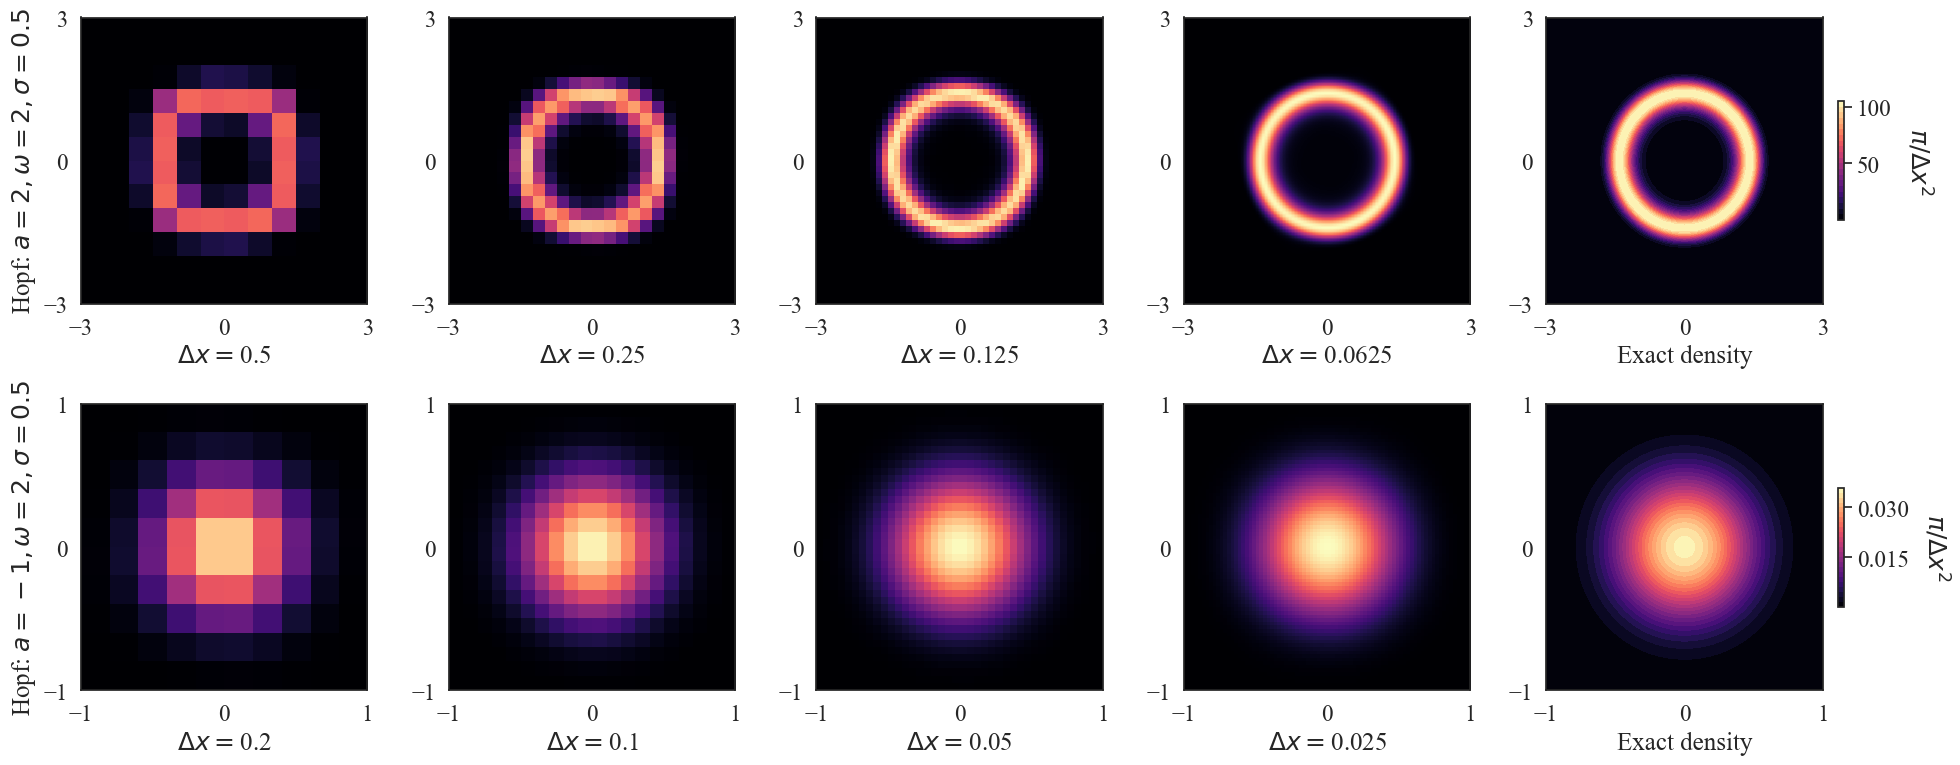

In [35]:
fig, ax = plt.subplots(2, 5)
fig.set_size_inches(20, 8)
cmap = plt.get_cmap('magma')

x1 = np.linspace(-3, 3, 101)
y1 = np.linspace(-3, 3, 101)
X1, Y1 = np.meshgrid(x1, y1)
Z1 = hopf_stationary_density(X1,Y1,a=2,sigma=0.5)
c = ax[0,4].contourf(X1, Y1, Z1, levels=25, cmap='magma',alpha=1)
ax[0,4].set_xticks([-3, 0, 3])  
ax[0,4].set_yticks([-3, 0, 3])
c.set_edgecolor("face")
cbar2 = fig.colorbar(c, ax=ax[0,4], orientation='vertical', fraction=0.02, pad=0.05)
cbar2.set_label(r'$\pi/\Delta x^2$', rotation=270, labelpad=30)
cbar2.set_ticks([50,100])


x2 = np.linspace(-1, 1, 101)
y2 = np.linspace(-1, 1, 101)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = hopf_stationary_density(X2,Y2,a=-1,sigma=0.5)
c = ax[1,4].contourf(X2, Y2, Z2, levels=25, cmap='magma',alpha=1)
ax[1,4].set_xticks([-1, 0, 1])  
ax[1,4].set_yticks([-1, 0, 1])
c.set_edgecolor("face")
cbar2 = fig.colorbar(c, ax=ax[1,4], orientation='vertical', fraction=0.02, pad=0.05)
cbar2.set_label(r'$\pi/\Delta x^2$', rotation=270, labelpad=30)
cbar2.set_ticks([0.015,0.03])


dx1_range = [0.5,0.25,0.125,0.0625]
grid_list1 = []
dist_list1 = []
dx2_range = [0.2,0.1,0.05,0.025]
grid_list2 = []
dist_list2 = []

vmin1 = float('inf')
vmax1 = float('-inf')
vmin2 = float('inf')
vmax2 = float('-inf')

for i in range(len(dx1_range)):
    dx1 = dx1_range[i]
    xmin1 = -3; xmax1 = 3
    ymin1 = -3; ymax1 = 3
    a =2; sigma = 0.5; omega = 2
    def f_x(x,y):
        return (a-x**2-y**2)*x-omega*y 
        
    def f_y(x,y):
        return (a-x**2-y**2)*y+omega*x 
        
    def D_xx(x,y):
        return (sigma**2)/2
        
    def D_yy(x,y):
        return (sigma**2)/2
    
    L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_reflecting_boundaries(
        [f_x, f_y], [D_xx, D_yy], dx1, xmin1, xmax1, dx1, ymin1, ymax1
    )
    
    p_ss = h.efficient_stationary_dist(L).reshape(x_midpoints.shape[0], y_midpoints.shape[0]) / (dx1**2)
    grid_list1.append([x_midpoints, y_midpoints])
    dist_list1.append(p_ss)
    vmin1 = min(vmin1, p_ss.min())
    vmax1 = max(vmax1, p_ss.max())

    dx2 = dx2_range[i]
    xmin2 = -1; xmax2 = 1
    ymin2 = -1; ymax2 = 1
    a = -1; sigma = 0.5; omega = 2
    
    def f_x(x,y):
        return (a-x**2-y**2)*x-omega*y 
        
    def f_y(x,y):
        return (a-x**2-y**2)*y+omega*x 
        
    def D_xx(x,y):
        return (sigma**2)/2
        
    def D_yy(x,y):
        return (sigma**2)/2
    
    L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_reflecting_boundaries(
        [f_x, f_y], [D_xx, D_yy], dx2, xmin2, xmax2, dx2, ymin2, ymax2
    )
    
    p_ss = h.efficient_stationary_dist(L).reshape(x_midpoints.shape[0], y_midpoints.shape[0]) / (dx2**2)
    grid_list2.append([x_midpoints, y_midpoints])
    dist_list2.append(p_ss)
    vmin2 = min(vmin2, p_ss.min())
    vmax2 = max(vmax2, p_ss.max())

norm1 = mcolors.Normalize(vmin=vmin1, vmax=vmax1)
norm2 = mcolors.Normalize(vmin=vmin2, vmax=vmax2)

for i, p_ss1 in enumerate(dist_list1):
    im = ax[0,i].imshow(p_ss1, extent=[xmin1, xmax1, ymin1, ymax1], 
                      origin='lower', cmap=cmap, norm=norm1)
    ax[0,i].set_xlabel(r'$\Delta x = $' + str(dx1_range[i]))
    ax[0,i].set_aspect('equal')
    ax[0,i].set_xticks([-3, 0, 3])  
    ax[0,i].set_yticks([-3, 0, 3])

    p_ss2 = dist_list2[i]
    
    im = ax[1,i].imshow(p_ss2, extent=[xmin2, xmax2, ymin2, ymax2], 
                      origin='lower', cmap=cmap, norm=norm2)
    ax[1,i].set_xlabel(r'$\Delta x = $' + str(dx2_range[i]))
    ax[1,i].set_aspect('equal')
    ax[1,i].set_xticks([-1, 0, 1])  
    ax[1,i].set_yticks([-1, 0, 1])

ax[0,0].set_ylabel(f"Hopf: " + str(r'$a = 2, \omega = 2, \sigma = 0.5$'))
ax[0,4].set_xlabel("Exact density")
ax[1,0].set_ylabel(f"Hopf: " + str(r'$a = -1, \omega = 2, \sigma = 0.5$'))
ax[1,4].set_xlabel("Exact density")

plt.tight_layout()
#plt.savefig("Hopf_density.pdf", format="pdf", bbox_inches="tight")
plt.show()

We can also assess the convergence of the EPR as a function of the step-size

In [54]:
sigma = 0.5; a = 2
omega_range1 = np.linspace(0,4,11)
EPR_discrete1 = np.zeros((len(omega_range1),len(dx1_range)))

for i, omega in enumerate(omega_range1):
    for j, dx1 in enumerate(dx1_range):
        def f_x(x,y):
            return (a-x**2-y**2)*x-omega*y 
        
        def f_y(x,y):
            return (a-x**2-y**2)*y+omega*x 
        
        def D_xx(x,y):
            return (sigma**2)/2
        
        def D_yy(x,y):
            return (sigma**2)/2
            
        L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_reflecting_boundaries(
            [f_x, f_y], [D_xx, D_yy], dx1, xmin1, xmax1, dx1, ymin1, ymax1
        )
        p_ss = h.efficient_stationary_dist(L)

        EPR_discrete1[i,j] = h.EPR_MC(L,p_ss)


a = -1
EPR_discrete2 = np.zeros((len(omega_range1),len(dx2_range)))

for i, omega in enumerate(omega_range1):
    for j, dx2 in enumerate(dx2_range):
        def f_x(x,y):
            return (a-x**2-y**2)*x-omega*y 
        
        def f_y(x,y):
            return (a-x**2-y**2)*y+omega*x 
        
        def D_xx(x,y):
            return (sigma**2)/2
        
        def D_yy(x,y):
            return (sigma**2)/2
            
        L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_reflecting_boundaries(
            [f_x, f_y], [D_xx, D_yy], dx2, xmin2, xmax2, dx2, ymin2, ymax2
        )
        p_ss = h.efficient_stationary_dist(L)

        EPR_discrete2[i,j] = h.EPR_MC(L,p_ss)

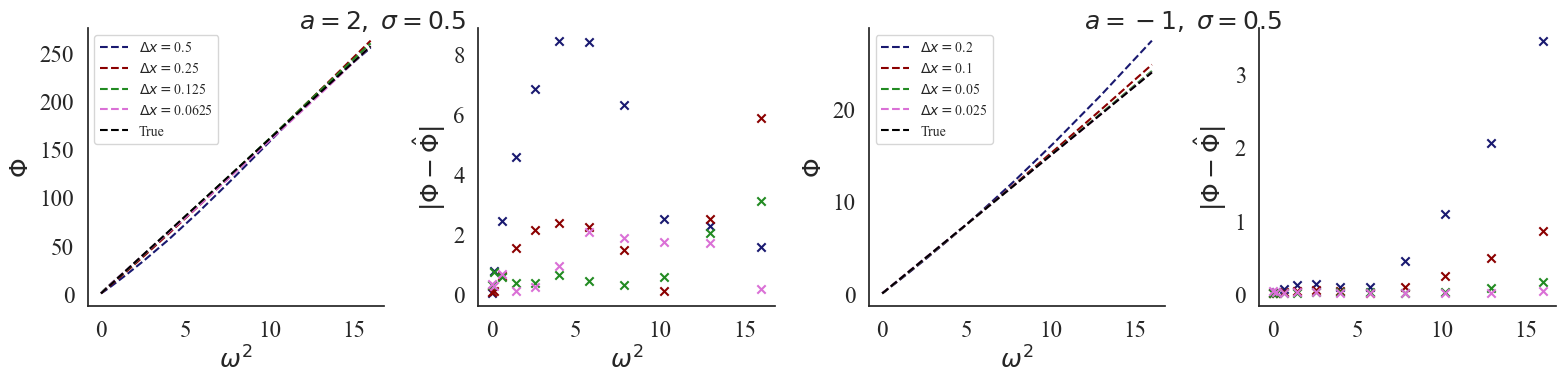

In [69]:
fig, ax = plt.subplots(1, 4)
fig.set_size_inches(16, 4)

EPR_true1 = Hopf_EPR(2,0.5,omega_range1)
EPR_true2 = Hopf_EPR(-1,0.5,omega_range1)

cols = ['midnightblue','darkred','forestgreen','orchid']

for i in range(0,len(dx1_range)):
    ax[0].plot(omega_range1**2,EPR_discrete1[:,i],color=cols[i],linestyle='dashed',label = r'$\Delta x = $' + str(dx1_range[i]))
    ax[1].scatter(omega_range1**2,np.abs(EPR_discrete1[:,i] - EPR_true1),color=cols[i],label = r'$\Delta x = $' + str(dx1_range[i]), marker ='x')
    ax[2].plot(omega_range1**2,EPR_discrete2[:,i],color=cols[i],linestyle='dashed',label = r'$\Delta x = $' + str(dx2_range[i]))
    ax[3].scatter(omega_range1**2,np.abs(EPR_discrete2[:,i] - EPR_true2),color=cols[i],label = r'$\Delta x = $' + str(dx2_range[i]), marker ='x')

ax[0].plot(omega_range1**2,EPR_true1,color='black',linestyle='dashed',label = 'True')
ax[2].plot(omega_range1**2,EPR_true2,color='black',linestyle='dashed',label = 'True')
ax[0].set_xlabel(r'$\omega^2$')
ax[1].set_xlabel(r'$\omega^2$')
ax[1].set_ylabel(r'$|\Phi-\hat{\Phi}|$')
ax[3].set_ylabel(r'$|\Phi-\hat{\Phi}|$')

ax[0].set_ylabel(r'$\Phi$')
ax[2].set_xlabel(r'$\omega^2$')
ax[2].set_ylabel(r'$\Phi$')

ax[0].legend(fontsize=10)
ax[2].legend(fontsize=10)

(subfig_top, subfig_bottom) = fig.subfigures(nrows=1, ncols=2)
subfig_top.suptitle(r'$a=2, \;\sigma = 0.5$', fontsize=18)
subfig_bottom.suptitle(r'$a=-1,\; \sigma = 0.5$', fontsize=18)


sns.despine()
plt.tight_layout()
plt.savefig("Hopf_EPR_Conv.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [5]:
dx = 0.125
a_range = np.linspace(-1,2,11)
omega_range = np.linspace(0,4,11)

numerical_EPR = np.zeros((len(a_range),len(omega_range)))

xmin1 = -3; xmax1 = 3
ymin1 = -3; ymax1 = 3

for a_i, a in enumerate(a_range):
    for w_i, omega in enumerate(omega_range):
        def f_x(x,y):
            return (a-x**2-y**2)*x-omega*y 
        
        def f_y(x,y):
            return (a-x**2-y**2)*y+omega*x 
        
        def D_xx(x,y):
            return (sigma**2)/2
        
        def D_yy(x,y):
            return (sigma**2)/2
            
        L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_reflecting_boundaries(
            [f_x, f_y], [D_xx, D_yy], dx, xmin1, xmax1, dx, ymin1, ymax1
        )
        p_ss = h.efficient_stationary_dist(L)

        numerical_EPR[a_i,w_i] = h.EPR_MC(L,p_ss)

-1.0
-0.7
-0.4
-0.10000000000000009
0.19999999999999996
0.5
0.7999999999999998
1.1
1.4
1.6999999999999997
2.0


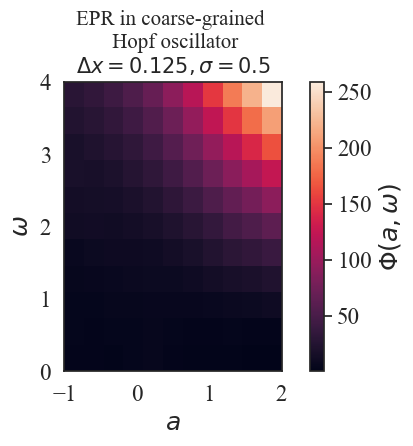

In [7]:
fig, ax = plt.subplots(1,1)
cp = ax.imshow(numerical_EPR.T, extent = [-1, 2, 4, 0])
ax.invert_yaxis()
c = fig.colorbar(cp, ax=ax, label=r'$\Phi(a,\omega)$')
ax.set_xlabel(r'$a$')
ax.set_ylabel(r'$\omega$')
ax.set_title(f'EPR in coarse-grained \n Hopf oscillator\n' + r'$\Delta x = 0.125, \sigma = 0.5$',fontsize = 15)
plt.tight_layout()
plt.savefig("HopfHeatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Unsolvable models

### The van der Pol oscillator

We now consider the stochastic van der Pol oscillator given by

$$
    dx(t)= \theta y\; dt+ \sigma \;dW_x(t),
$$
$$
    dy(t)= -\theta x + \mu y (1-x^2)\; dt+ \sigma \;dW_y(t).
$$

This model does not have a solvable steady-state, so we can instead use our coarse-grained description to explore its steady-state behaviour.

In [4]:
theta = 1; mu = 2

def f_x(x,y):
    return theta*y
        
def f_y(x,y):
    return -theta*x + mu*y*(1-x**2)
        
def D_xx(x,y):
    return (sigma**2)/2
        
def D_yy(x,y):
    return (sigma**2)/2

First, we consider the stationary distribution as a function of the step-size $\Delta x $.

/var/folders/j3/3jf2wkbj5756yfdv4zjq5j300000gn/T/ipykernel_84460/3041343548.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


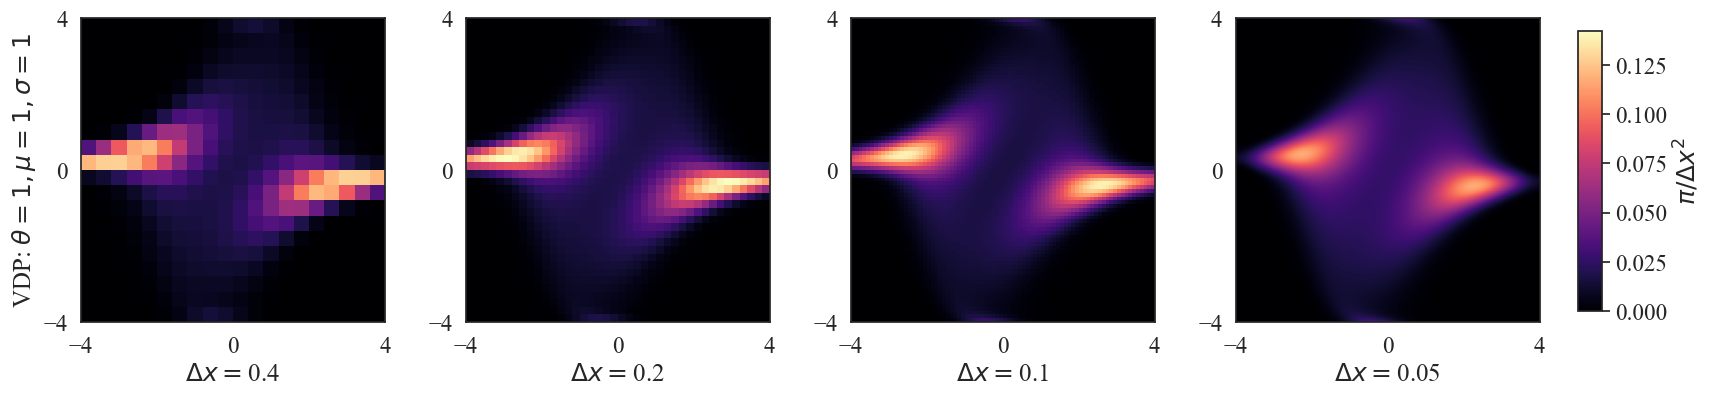

In [34]:
fig, ax = plt.subplots(1, 4)
fig.set_size_inches(16, 4)
cmap = plt.get_cmap('magma')


dx_range = [0.4,0.2,0.1,0.05]
grid_list = []
dist_list = []

vmin = float('inf')
vmax = float('-inf')

xmin = -4; xmax = 4
ymin = -4; ymax = 4


theta = 1; mu = 1; sigma = 1

for i in range(len(dx_range)):
    dx = dx_range[i]
    
    def f_x(x,y):
        return theta*y
    def f_y(x,y):
        return -theta*x + mu*y*(1-x**2) 
    def D_xx(x,y):
        return (sigma**2)/2    
    def D_yy(x,y):
        return (sigma**2)/2
    
    L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_reflecting_boundaries(
        [f_x, f_y], [D_xx, D_yy], dx, xmin, xmax, dx, ymin, ymax
    )
    
    p_ss = h.efficient_stationary_dist(L).reshape(x_midpoints.shape[0], y_midpoints.shape[0]) / (dx**2)
    grid_list.append([x_midpoints, y_midpoints])
    dist_list.append(p_ss)
    vmin = min(vmin, p_ss.min())
    vmax = max(vmax, p_ss.max())

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

for i, p_ss in enumerate(dist_list):
    im = ax[i].imshow(p_ss.T, extent=[xmin, xmax, ymin, ymax], 
                          origin='lower', cmap=cmap, norm=norm)
    ax[i].set_xlabel(r'$\Delta x = $' + str(dx_range[i]))
    ax[i].set_aspect('equal')
    ax[i].set_xticks([xmin, 0, xmax])  
    ax[i].set_yticks([xmin, 0, xmax])

ax[0].set_ylabel('VDP: ' + r'$\theta = 1, \mu = 1, \sigma = 1$') 

fig.subplots_adjust(right=0.88)  

cbar_ax = fig.add_axes([1, 0.2, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'$\pi/\Delta x^2$')

plt.tight_layout()
plt.savefig("VDP_stationary.pdf", format="pdf", bbox_inches="tight")
plt.show()

We can check that this agrees with the longtime behaviour of the FP PDE by numerically solving this using the Crank-Nicholson scheme.

The Crank-Nicholson scheme is given by,

$$
p_{t+1} = B^{-1}Ap_t,
$$

where

$$
B = I - \frac{1}{2}\Delta t L,
$$
$$
A = I + \frac{1}{2}\Delta t L,
$$

which should tend to the same stationary distribution. We begin with an intial zero-mean Gaussian distribution.

In [31]:
dx = 0.05

xmin = -4; xmax = 4
ymin = -4; ymax = 4

L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_reflecting_boundaries(
        [f_x, f_y], [D_xx, D_yy], dx, xmin, xmax, dx, ymin, ymax
    )

Nl,_ = L.shape
N = x_midpoints.shape[0]
M = y_midpoints.shape[0]
dt = 0.2
T = 2
T_N = int(T/dt)
p_t = (1/(Nl))*np.ones((N,M,T_N))

X, Y = np.meshgrid(x_midpoints, y_midpoints, indexing='ij')
sigma = 1  
gaussian = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
gaussian /= np.sum(gaussian)

p_t[:, :, 0] = gaussian

I = np.eye(Nl)
B = csr_matrix(I-0.5*dt*L)
A = csr_matrix(I+0.5*dt*L)
Binv = spsolve(B, I)

for t in range(0,T_N-1):
    p_t[:,:,t+1] = (Binv@A@(p_t[:,:,t].flatten())).reshape(N,M)

0
1
2
3
4
5
6
7
8


/var/folders/j3/3jf2wkbj5756yfdv4zjq5j300000gn/T/ipykernel_84460/2103518149.py:21: UserWarning: Adding colorbar to a different Figure <Figure size 1600x400 with 5 Axes> than <Figure size 2000x1000 with 9 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(im, cax=cbar_ax)
/var/folders/j3/3jf2wkbj5756yfdv4zjq5j300000gn/T/ipykernel_84460/2103518149.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


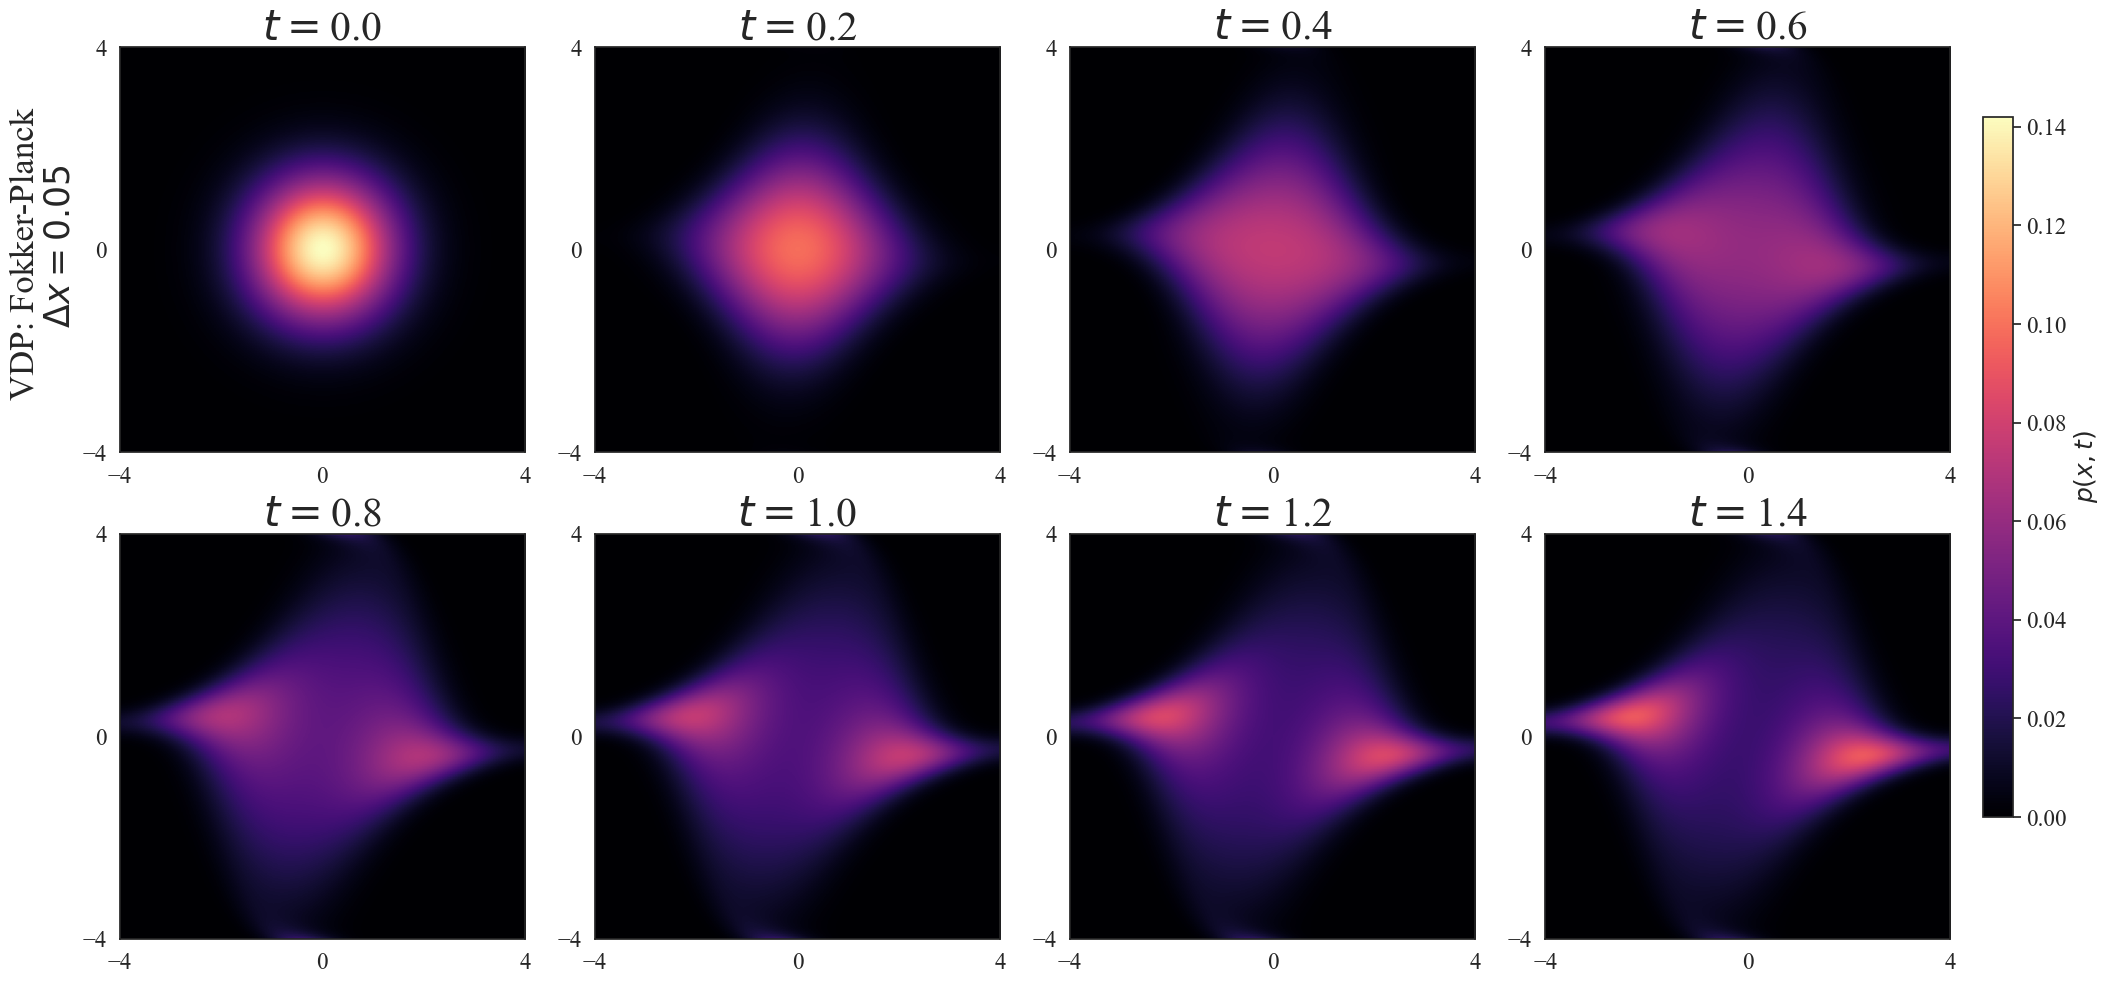

In [36]:
fig, ax = plt.subplots(2,4)
fig.set_size_inches((20,10))
vmax = p_t.max()
norm = plt.Normalize(vmin=0, vmax=vmax)

for i in range(4):
    ax[0, i].imshow(p_t[:, :, i].T, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='magma',norm = norm)
    ax[1, i].imshow(p_t[:, :, i + 5].T, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='magma', norm = norm)
    for j in range(0,2):
        ax[j,i].set_aspect('equal')
        ax[j,i].set_xticks([xmin, 0, xmax])  
        ax[j,i].set_yticks([xmin, 0, xmax])
    ax[0,i].set_title(r'$t = $' + str(i*dt)[:3], fontsize = 30)
    ax[1,i].set_title(r'$t = $' + str((4+i)*dt)[:3], fontsize = 30)

ax[0,0].set_ylabel(f'VDP: Fokker-Planck \n ' + r'$\Delta x = 0.05$',fontsize = 25)

fig.subplots_adjust(right=0.88)  

cbar_ax = fig.add_axes([1, 0.175, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'$p(x,t)$')

plt.tight_layout()
plt.savefig("VDP_FP.pdf", format="pdf", bbox_inches="tight")
plt.show()

Next, we investigate how the shape of the stationary distribution changes with different parameters

1.0000000000000002
1.0
0.9999999999999999


/var/folders/j3/3jf2wkbj5756yfdv4zjq5j300000gn/T/ipykernel_84460/456963890.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


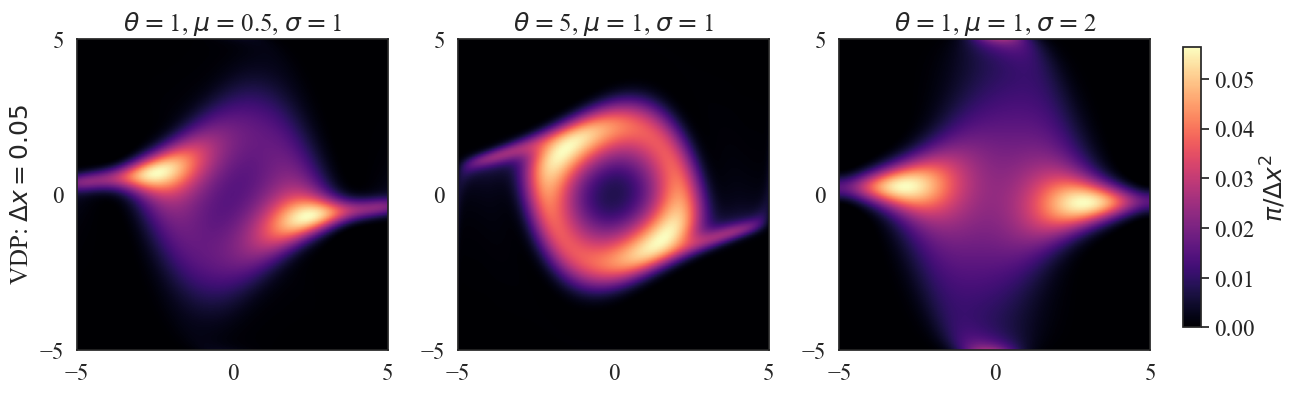

In [41]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(12, 4)
cmap = plt.get_cmap('magma')


dist_list =[]
grid_list =[]

dx = 0.05 

xmin = -5; xmax = 5
ymin = -5; ymax = 5

params = [
    [1,3,1],
    [5,1,1],
    [1,1,2]
]

for i, pset in enumerate(params):
    theta, mu, sigma = pset
    
    def f_x(x,y):
        return theta*y
    def f_y(x,y):
        return -theta*x + mu*y*(1-x**2) 
    def D_xx(x,y):
        return (sigma**2)/2    
    def D_yy(x,y):
        return (sigma**2)/2
    
    L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_reflecting_boundaries(
        [f_x, f_y], [D_xx, D_yy], dx, xmin, xmax, dx, ymin, ymax
    )
    
    p_ss = h.efficient_stationary_dist(L).reshape(x_midpoints.shape[0], y_midpoints.shape[0]) / (dx**2)
    print(np.sum(p_ss)*dx**2)
    grid_list.append([x_midpoints, y_midpoints])
    dist_list.append(p_ss)


for i, p_ss in enumerate(dist_list):
    vmin = np.max([0,np.min(p_ss)]); vmax = np.max(p_ss)
    im = ax[i].imshow(p_ss.T, extent=[xmin, xmax, ymin, ymax], 
                          origin='lower', cmap=cmap)
    ax[i].set_aspect('equal')
    ax[i].set_xticks([xmin, 0, xmax])  
    ax[i].set_yticks([xmin, 0, xmax])
    theta, mu, sigma = params[i]
    ax[i].set_title(r'$\theta=$' + str(theta) +r', $\mu =$' + str(mu) + r', $\sigma =$' + str(sigma))

ax[0].set_ylabel(r'VDP: $\Delta x = 0.05$') 

fig.subplots_adjust(right=0.88)  

cbar_ax = fig.add_axes([1, 0.175, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'$\pi/\Delta x^2$')


plt.tight_layout()
plt.savefig("VDP_NESS.pdf", format="pdf", bbox_inches="tight")
plt.show()

Finally, we can use the coarse-graining to investigate how the EPR varies as a function of the parameters $\mu$ and $\theta$.

In [67]:
mu_space = np.linspace(0,2,11)
theta_space = np.linspace(1,4,12)

dx = 0.1

numerical_EPR = np.zeros((len(mu_space),len(theta_space)))

for mu_i, mu in enumerate(mu_space):
    for theta_i, theta in enumerate(theta_space):
        def f_x(x,y):
            return theta*y
        def f_y(x,y):
            return -theta*x + mu*y*(1-x**2) 
        def D_xx(x,y):
            return (sigma**2)/2    
        def D_yy(x,y):
            return (sigma**2)/2
            
        L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_reflecting_boundaries(
            [f_x, f_y], [D_xx, D_yy], dx, xmin, xmax, dx, ymin, ymax
        )
        
        p_ss = h.efficient_stationary_dist(L)

        numerical_EPR[mu_i,theta_i] = h.EPR_MC(L,p_ss)

0.0
0.2
0.4
0.6000000000000001
0.8
1.0
1.2000000000000002
1.4000000000000001
1.6
1.8
2.0


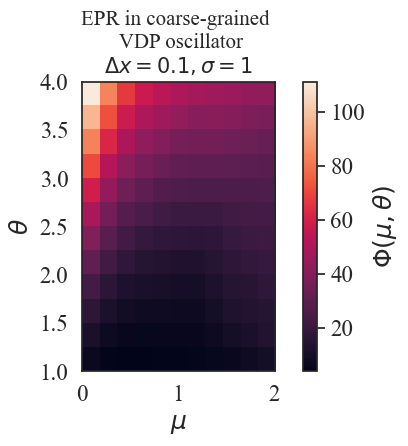

In [68]:
fig, ax = plt.subplots(1,1)
cp = ax.imshow(numerical_EPR.T, extent = [0, 2, 4, 1])
ax.invert_yaxis()
c = fig.colorbar(cp, ax=ax, label=r'$\Phi(\mu,\theta)$')
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$\theta$')
ax.set_title(f'EPR in coarse-grained \n VDP oscillator\n' + r'$\Delta x = 0.1, \sigma = 1$',fontsize = 15)
plt.tight_layout()
plt.savefig("VDPHeatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

### A pair of frustrated Kuramoto oscillators

We focus on the 2d system,

$$
d\theta_1(t) = \omega_1 + A_{12}\sin(\theta_2-\theta_1+\alpha)\;dt + \sigma\;dW_1(t)
$$
$$
d\theta_2(t) = \omega_2 + A_{21}\sin(\theta_1-\theta_2+\alpha)\;dt + \sigma\;dW_2(t),
$$

In [2]:
omega1 = 1; omega2 = 1; sigma = 1;
A12 = 1; A21 = 0.5; alpha = np.pi/4

def f_x(x,y):
    return omega1 + A12*np.sin(y-x+alpha)
        
def f_y(x,y):
    return omega2 + A21*np.sin(x-y+alpha)
        
def D_xx(x,y):
    return (sigma**2)/2
        
def D_yy(x,y):
    return (sigma**2)/2

First, we visualise this vector field on the domain $[0,2\pi)^2$ for a range of different parameter values.

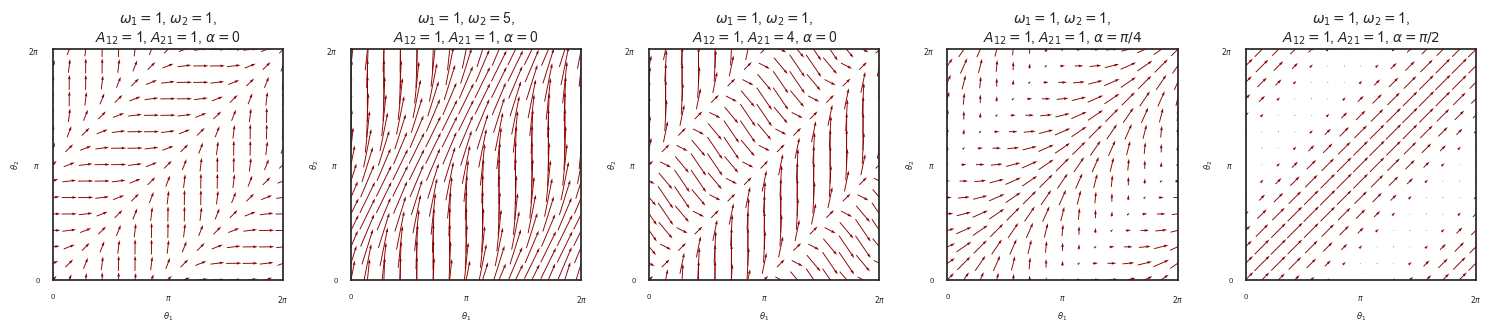

In [46]:
parameters =[
    [1,1,1,1,0],
    [1,5,1,1,0],
    [1,1,1,4,0],
    [1,1,1,1,np.pi/4],
    [1,1,1,1,np.pi/2]
]

fig, ax = plt.subplots(1,5)
fig.set_size_inches(15,3)
for i,params in enumerate(parameters):

    omega1, omega2, A12, A21, alpha = params

    def f_x(x,y):
        return omega1 + A12*np.sin(y-x+alpha)
        
    def f_y(x,y):
        return omega2 + A21*np.sin(x-y+alpha)
        
    x = np.linspace(0, 2*np.pi, 15)
    y = np.linspace(0, 2*np.pi, 15)
    X, Y = np.meshgrid(x, y)
    
    U = f_x(X, Y)
    V = f_y(X, Y)
    
    ax[i].quiver(X, Y, U, V, pivot='mid', color='darkred', scale=30)
    ax[i].set_xlabel(r'$\theta_1$')
    ax[i].set_ylabel(r'$\theta_2$')
    ax[i].set_xlim(0, 2*np.pi)
    ax[i].set_ylim(0, 2*np.pi)
    ax[i].set_xticks([0, np.pi, 2*np.pi], ['0', r'$\pi$', r'$2\pi$'])
    ax[i].set_yticks([0, np.pi, 2*np.pi], ['0', r'$\pi$', r'$2\pi$'])
    ax[i].set_aspect('equal')
    if i < 3:
        ax[i].set_title(r'$\omega_1 = $' + str(omega1) + r', $\omega_2 = $' + str(omega2) + ',' f'\n' + r'$A_{12} = $' + str(A12 )+ r', $A_{21} = $' + str(A21) + r', $\alpha = $' + str(alpha), fontsize = 10)
    if i == 3:
        ax[i].set_title(r'$\omega_1 = $' + str(omega1) + r', $\omega_2 = $' + str(omega2) + ',' f'\n' + r'$A_{12} = $' + str(A12 )+ r', $A_{21} = $' + str(A21) + r', $\alpha = \pi/4$', fontsize = 10)
    if i == 4:
        ax[i].set_title(r'$\omega_1 = $' + str(omega1) + r', $\omega_2 = $' + str(omega2) + ',' f'\n' + r'$A_{12} = $' + str(A12 )+ r', $A_{21} = $' + str(A21) + r', $\alpha = \pi/2$', fontsize = 10)
plt.tight_layout()
plt.savefig("Kuramoto_vf.pdf", format="pdf", bbox_inches="tight")
plt.show()

Using the coarse-grained dynamics with periodic boundaries, we can approximate the steady-state distribution in these various conditions.

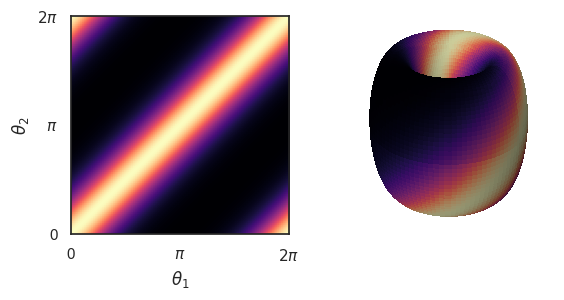

In [135]:
omega1 = 1; omega2 = 1; sigma = 1;
A12 = 1; A21 = 1; alpha = 0

def f_x(x,y):
    return omega1 + A12*np.sin(y-x+alpha)
        
def f_y(x,y):
    return omega2 + A21*np.sin(x-y+alpha)
        
def D_xx(x,y):
    return (sigma**2)/2
        
def D_yy(x,y):
    return (sigma**2)/2

xmin = 0; xmax = 2*np.pi
ymin = 0; ymax = 2*np.pi
dx = np.pi/50

L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_periodic_boundaries(
        [f_x, f_y], [D_xx, D_yy], dx, xmin, xmax, dx, ymin, ymax
    )

p_ss = h.efficient_stationary_dist(L).reshape(x_midpoints.shape[0], y_midpoints.shape[0]) / (dx**2)

theta = np.linspace(0, 2*np.pi, p_ss.shape[0])
phi = np.linspace(0, 2*np.pi, p_ss.shape[1])
theta, phi = np.meshgrid(theta, phi)

R = 2
r = 1 

X = (R + r * np.cos(phi)) * np.cos(theta)
Y = (R + r * np.cos(phi)) * np.sin(theta)
Z = r * np.sin(phi)

fig = plt.figure(figsize=(6, 3))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(p_ss.T, extent=[xmin, xmax, ymin, ymax], 
                              origin='lower', cmap=cmap)
ax1.set_xlabel(r'$\theta_1$')
ax1.set_ylabel(r'$\theta_2$')
ax1.set_xlim(0, 2*np.pi)
ax1.set_ylim(0, 2*np.pi)
ax1.set_xticks([0, np.pi, 2*np.pi], ['0', r'$\pi$', r'$2\pi$'])
ax1.set_yticks([0, np.pi, 2*np.pi], ['0', r'$\pi$', r'$2\pi$'])

ax2 = fig.add_subplot(1, 2, 2, projection='3d')

cmap = plt.get_cmap('magma')
norm = plt.Normalize(p_ss.min(), p_ss.max())
colors = cmap(norm(p_ss.T))

ax2.plot_surface(X, Y, Z, facecolors=colors, rstride=1, cstride=1, antialiased=False)
ax2.set_axis_off()
zoom_factor = 0.7
ax2.set_xlim([-R - r*zoom_factor, R + r*zoom_factor])
ax2.set_ylim([-R - r*zoom_factor, R + r*zoom_factor])
ax2.set_zlim([-r*zoom_factor, r*zoom_factor])

plt.tight_layout()
plt.show()

/var/folders/j3/3jf2wkbj5756yfdv4zjq5j300000gn/T/ipykernel_23160/456440973.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


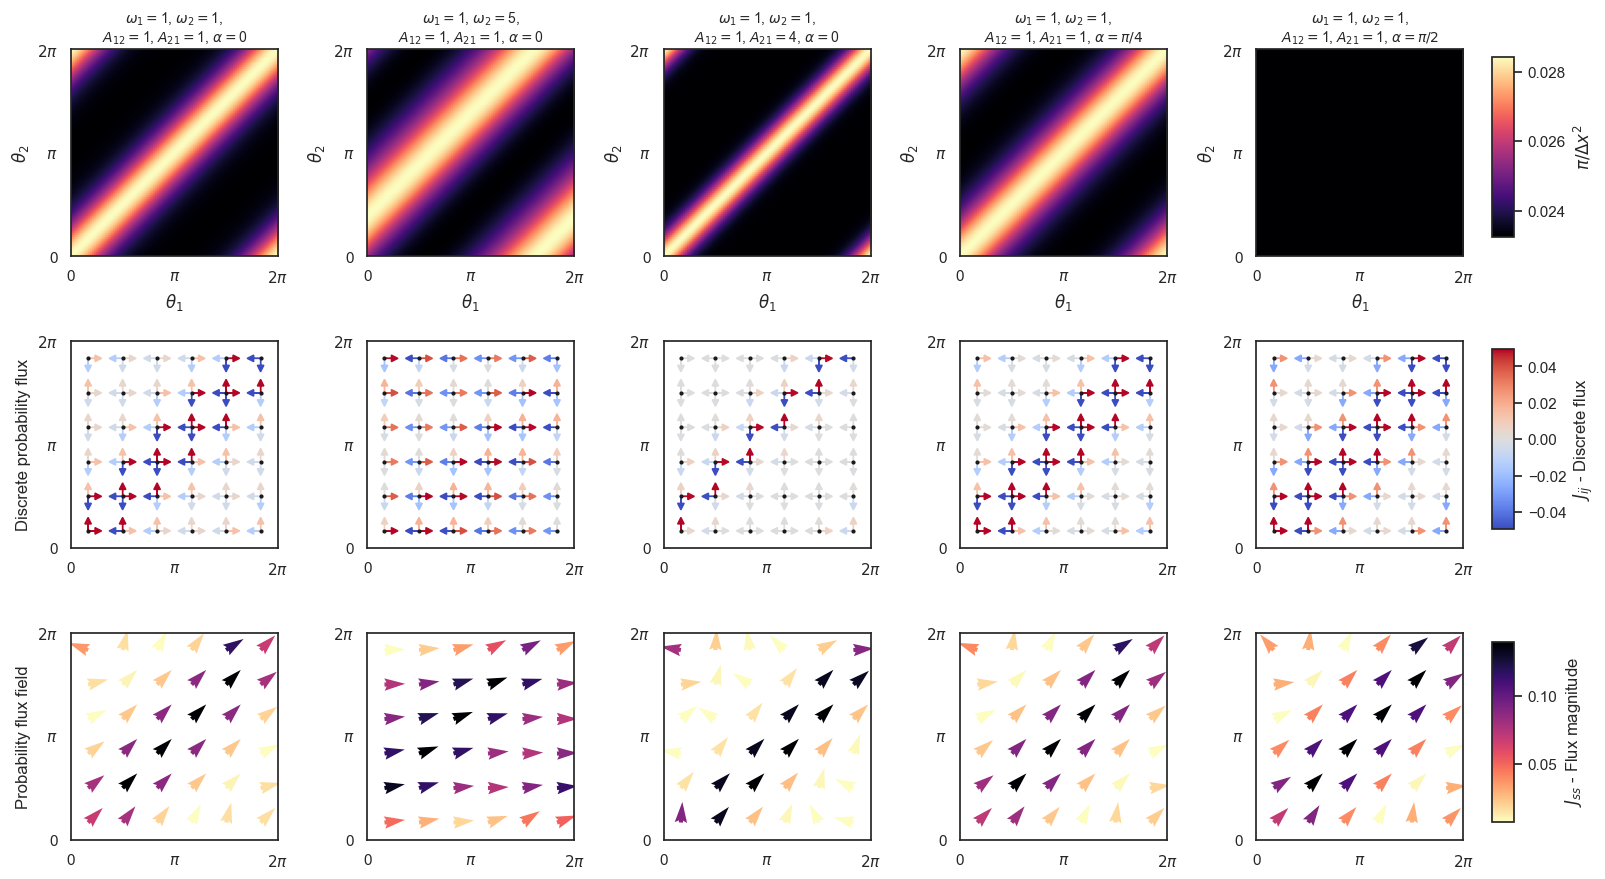

In [ ]:
fig, ax = plt.subplots(3,5)
fig.set_size_inches(15,9)
cmap = plt.get_cmap('magma')
sns.set(style = 'white', font_scale = 1)
parameters =[
    [1,1,1,1,0],
    [1,5,1,1,0],
    [1,1,1,4,0],
    [1,1,1,1,np.pi/4],
    [1,1,1,1,np.pi/2]
]
xmin = 0; xmax = 2*np.pi
ymin = 0; ymax = 2*np.pi
dx1 = np.pi/3
dy1 = dx1

dx2 = np.pi/50


for i,params in enumerate(parameters):

    omega1, omega2, A12, A21, alpha = params

    def f_x(x,y):
        return omega1 + A12*np.sin(y-x+alpha)
        
    def f_y(x,y):
        return omega2 + A21*np.sin(x-y+alpha)
        
    L1, x_midpoints1, y_midpoints1, x_left, x_right, y_left, y_right = h.SG_2d_periodic_boundaries(
        [f_x, f_y], [D_xx, D_yy], dx1, xmin, xmax, dx1, ymin, ymax
    )

    L2, x_midpoints2, y_midpoints2, x_left, x_right, y_left, y_right = h.SG_2d_periodic_boundaries(
        [f_x, f_y], [D_xx, D_yy], dx2, xmin, xmax, dx2, ymin, ymax
    )

    p_ss_flat1 = h.efficient_stationary_dist(L1)
    p_ss1 = p_ss_flat1.reshape(x_midpoints1.shape[0], y_midpoints1.shape[0]) / (dx1**2)
    J = h.discrete_flux_SG_periodic(L1,p_ss_flat1,x_midpoints1.shape[0], y_midpoints1.shape[0])
    
    p_ss_flat2 = h.efficient_stationary_dist(L2)
    p_ss2 = p_ss_flat2.reshape(x_midpoints2.shape[0], y_midpoints2.shape[0]) / (dx2**2)
    
    norm = cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=np.min(J), vmax=np.max(J)))
    ax[0,i].imshow(p_ss2.T, extent=[xmin, xmax, ymin, ymax], 
                              origin='lower', cmap=cmap)
    
    for j in range(0,3):
        if j == 0:
            ax[j,i].set_ylabel(r'$\theta_2$')
            ax[j,i].set_xlabel(r'$\theta_1$')
        ax[j,i].set_xlim(0, 2*np.pi)
        ax[j,i].set_ylim(0, 2*np.pi)
        ax[j,i].set_xticks([0, np.pi, 2*np.pi], ['0', r'$\pi$', r'$2\pi$'])
        ax[j,i].set_yticks([0, np.pi, 2*np.pi], ['0', r'$\pi$', r'$2\pi$'])
        ax[j,i].set_aspect('equal')

    ax[1,0].set_ylabel(r'Discrete probability flux')
    ax[2,0].set_ylabel(r'Probability flux field')
    
    if i < 3:
        ax[0,i].set_title(r'$\omega_1 = $' + str(omega1) + r', $\omega_2 = $' + str(omega2) + ',' f'\n' + r'$A_{12} = $' + str(A12 )+ r', $A_{21} = $' + str(A21) + r', $\alpha = $' + str(alpha),fontsize=10)
    if i == 3:
        ax[0,i].set_title(r'$\omega_1 = $' + str(omega1) + r', $\omega_2 = $' + str(omega2) + ',' f'\n' + r'$A_{12} = $' + str(A12 )+ r', $A_{21} = $' + str(A21) + r', $\alpha = \pi/4$',fontsize=10)
    if i == 4:
        ax[0,i].set_title(r'$\omega_1 = $' + str(omega1) + r', $\omega_2 = $' + str(omega2) + ',' f'\n' + r'$A_{12} = $' + str(A12 )+ r', $A_{21} = $' + str(A21) + r', $\alpha = \pi/2$',fontsize=10)

    Ju = np.zeros((len(x_midpoints1),len(y_midpoints1)))
    Jv = np.zeros((len(x_midpoints1),len(y_midpoints1)))
    
    for k in range(len(x_midpoints1)):
        for l in range(len(y_midpoints1)):
            x, y = x_midpoints1[k], y_midpoints1[l]
            ax[1,i].plot(x, y, 'ko',markersize=2)  
    
            idx = l * len(x_midpoints1) + k
    
            if k < len(x_midpoints1) - 1:  
                right_idx = idx + 1
                magnitude = J[idx, right_idx]
                color = norm.to_rgba(magnitude)
                ax[1,i].arrow(x, y, dx1 * 0.2, 0, head_width=0.2, head_length=0.2, fc=color, ec=color)
            if k > 0: 
                left_idx = idx - 1
                magnitude = J[idx, left_idx]
                color = norm.to_rgba(magnitude)
                ax[1,i].arrow(x, y, -dx1 * 0.2, 0, head_width=0.2, head_length=0.2, fc=color, ec=color)
            if l < len(y_midpoints1) - 1: 
                up_idx = idx + len(x_midpoints1)
                magnitude = J[idx, up_idx]
                color = norm.to_rgba(magnitude)
                ax[1,i].arrow(x, y, 0, dy1 * 0.2, head_width=0.2, head_length=0.2, fc=color, ec=color)
            if l > 0:  
                down_idx = idx - len(x_midpoints1)
                magnitude = J[idx, down_idx]
                color = norm.to_rgba(magnitude)
                ax[1,i].arrow(x, y, 0, -dy1 * 0.2, head_width=0.2, head_length=0.2, fc=color, ec=color)

            Ju[k,l] = J[idx, right_idx] - J[idx, left_idx]
            Jv[k,l] = J[idx, up_idx] - J[idx, down_idx]
    
    xx, yy = np.meshgrid(x_midpoints1, y_midpoints1)
    magnitude = np.sqrt(Ju**2 + Jv**2)
    Ju_norm = Ju/magnitude
    Jv_norm = Jv/magnitude
    ax[2,i].quiver(xx, yy, Ju_norm, Jv_norm, magnitude, cmap='magma_r',width = 0.02,scale = 10)

cbar_ax0 = fig.add_axes([1, 0.725, 0.015, 0.2])
cbar0 = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=np.min(p_ss2), vmax=np.max(p_ss2))),
    cax=cbar_ax0
)
cbar0.set_label(r'$\pi/\Delta x^2$')

cbar_ax1 = fig.add_axes([1, 0.4, 0.015, 0.2])
cbar1 = fig.colorbar(norm, cax=cbar_ax1)
cbar1.set_label(r'$J_{ij}$ - Discrete flux')

cbar_ax2 = fig.add_axes([1, 0.075, 0.015, 0.2])
cbar2 = fig.colorbar(
    plt.cm.ScalarMappable(cmap='magma_r', norm=plt.Normalize(vmin=np.min(magnitude), vmax=np.max(magnitude))),
    cax=cbar_ax2
)
cbar2.set_label(r'$J_{ss}$ - Flux magnitude')
plt.tight_layout()
#plt.savefig("KuramotoNESS.pdf", format="pdf", bbox_inches="tight")
plt.show()

Now, we can see how the EPR of the coupled Kuramoto processes vary as a function of the parameters. We begin by varying the asymmetry of the coupling strengths.

In [20]:
A12_space = np.linspace(-2,2,11)
A21_space = np.linspace(-2,2,11)

omega1 = 1; omega2 = 1; sigma = 1; alpha = 0

dx = np.pi/25

xmin = 0; xmax = 2*np.pi
ymin = 0; ymax = 2*np.pi

numerical_EPR = np.zeros((len(A12_space),len(A21_space)))

for A12_i, A12 in enumerate(A12_space):
    for A21_i, A21 in enumerate(A21_space):
        
        def f_x(x,y):
            return omega1 + A12*np.sin(y-x+alpha)
        def f_y(x,y):
            return omega2 + A21*np.sin(x-y+alpha)
        def D_xx(x,y):
            return (sigma**2)/2    
        def D_yy(x,y):
            return (sigma**2)/2
            
        L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_periodic_boundaries(
            [f_x, f_y], [D_xx, D_yy], dx, xmin, xmax, dx, ymin, ymax
        )
        
        p_ss = h.efficient_stationary_dist(L)

        numerical_EPR[A12_i,A21_i] = h.EPR_MC(L,p_ss)

-2.0
-1.6
-1.2
-0.7999999999999998
-0.3999999999999999
0.0
0.40000000000000036
0.8000000000000003
1.2000000000000002
1.6
2.0


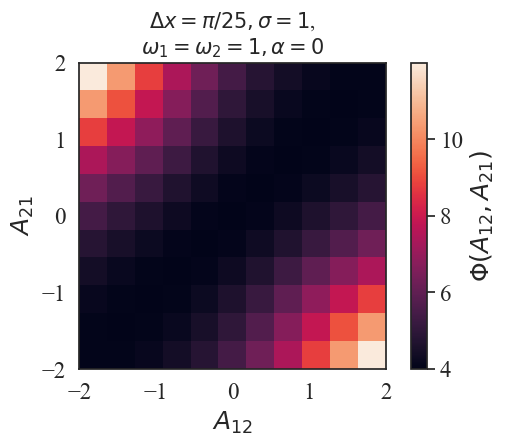

In [22]:
fig, ax = plt.subplots(1,1)
cp = ax.imshow(numerical_EPR.T, extent = [-2, 2, 2, -2])
ax.invert_yaxis()
c = fig.colorbar(cp, ax=ax, label=r'$\Phi(A_{12},A_{21})$')
ax.set_xlabel(r'$A_{12}$')
ax.set_ylabel(r'$A_{21}$')
ax.set_title(r'$\Delta x = \pi/25, \sigma = 1$,' + f'\n' + r'$\omega_{1} = \omega_{2} = 1, \alpha = 0$',fontsize = 15)
plt.tight_layout()
plt.savefig("KurAsymm.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [14]:
o1_space = np.linspace(0,2,11)
o2_space = np.linspace(0,2,11)

A12 = 1; A21 = 1; sigma = 1; alpha = 0

dx = np.pi/25

xmin = 0; xmax = 2*np.pi
ymin = 0; ymax = 2*np.pi

numerical_EPR = np.zeros((len(o1_space),len(o2_space)))

for w1_i, omega1 in enumerate(o1_space):
    for w2_i, omega2 in enumerate(o2_space):
        
        def f_x(x,y):
            return omega1 + A12*np.sin(y-x+alpha)
        def f_y(x,y):
            return omega2 + A21*np.sin(x-y+alpha)
        def D_xx(x,y):
            return (sigma**2)/2    
        def D_yy(x,y):
            return (sigma**2)/2
            
        L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_periodic_boundaries(
            [f_x, f_y], [D_xx, D_yy], dx, xmin, xmax, dx, ymin, ymax
        )
        
        p_ss = h.efficient_stationary_dist(L)

        numerical_EPR[w1_i,w2_i] = h.EPR_MC(L,p_ss)

0.0
0.2
0.4
0.6000000000000001
0.8
1.0
1.2000000000000002
1.4000000000000001
1.6
1.8
2.0


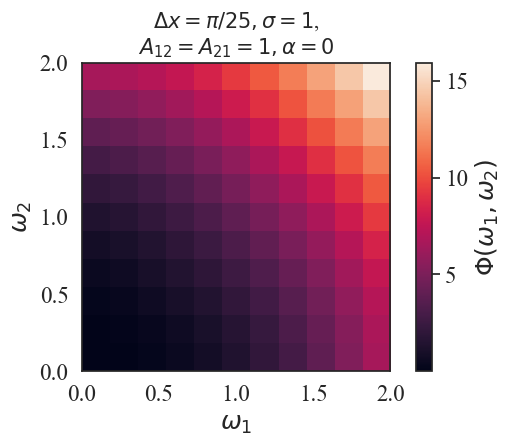

In [19]:
fig, ax = plt.subplots(1,1)
cp = ax.imshow(numerical_EPR.T, extent = [0, 2, 2, 0])
ax.invert_yaxis()
c = fig.colorbar(cp, ax=ax, label=r'$\Phi(\omega_{1},\omega_{2})$')
ax.set_xlabel(r'$\omega_{1}$')
ax.set_ylabel(r'$\omega_{2}$')
ax.set_title(r'$\Delta x = \pi/25, \sigma = 1$,' + f'\n' + r'$A_{12} = A_{21} = 1, \alpha = 0$',fontsize = 15)
plt.tight_layout()
plt.savefig("KurOmega.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [30]:
alpha_space = np.linspace(0,np.pi,17)
sigma_space = np.linspace(1,5,9)

A12 = 1; A21 = 1; omega1 = 1; omega2 = 1

dx = np.pi/25

xmin = 0; xmax = 2*np.pi
ymin = 0; ymax = 2*np.pi

numerical_EPR = np.zeros((len(alpha_space),len(sigma_space)))

for alpha_i, alpha in enumerate(alpha_space):
    print(alpha)
    for sigma_i, sigma in enumerate(sigma_space):
        
        def f_x(x,y):
            return omega1 + A12*np.sin(y-x+alpha)
        def f_y(x,y):
            return omega2 + A21*np.sin(x-y+alpha)
        def D_xx(x,y):
            return (sigma**2)/2    
        def D_yy(x,y):
            return (sigma**2)/2
            
        L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_periodic_boundaries(
            [f_x, f_y], [D_xx, D_yy], dx, xmin, xmax, dx, ymin, ymax
        )
        
        p_ss = h.efficient_stationary_dist(L)

        numerical_EPR[alpha_i,sigma_i] = h.EPR_MC(L,p_ss)

0.0
0.19634954084936207
0.39269908169872414
0.5890486225480862
0.7853981633974483
0.9817477042468103
1.1780972450961724
1.3744467859455345
1.5707963267948966
1.7671458676442586
1.9634954084936207
2.1598449493429825
2.356194490192345
2.552544031041707
2.748893571891069
2.945243112740431
3.141592653589793


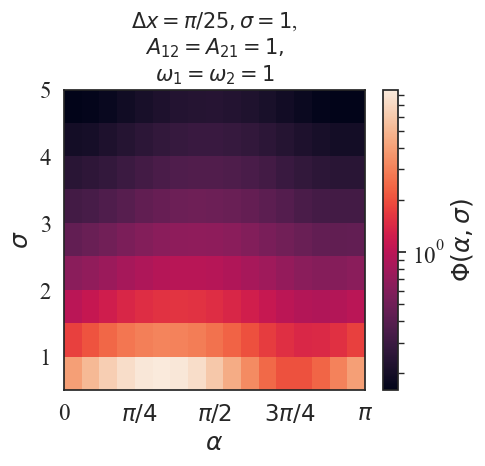

In [ ]:

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5.2,5)
cp = ax.imshow(
    numerical_EPR.T, 
    extent=[0, np.pi, 5, 0.5], 
    norm=LogNorm(vmin=np.nanmin(numerical_EPR[numerical_EPR > 0]), vmax=np.nanmax(numerical_EPR)), 
    aspect='auto'
)
ax.invert_yaxis()
c = fig.colorbar(cp, ax=ax, label=r'$\Phi(\alpha,\sigma)$')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\sigma$')
ax.set_title(r'$\Delta x = \pi/25, \sigma = 1$,' + '\n' + r'$A_{12} = A_{21} = 1,$' + '\n' + r'$\omega_{1} = \omega_{2} = 1$', fontsize=15)
ax.set_xticks([0,np.pi/4, np.pi/2, 3*np.pi/4, np.pi], ['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
plt.tight_layout()
#plt.savefig("KurFrustNoise.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Statistical inference of discrete state processes

In this next section, we consider the statistical inference of a discrete-state Markov process from a sequence of observed states, generated by coarse-graining a diffusive process. We will use the approximate maximum-likelihood estimator,

$$
\hat{L}_{ij} = \frac{N_{j\rightarrow i}}{T_j},
$$

where $N_{j \rightarrow i}$ is the number of observed transitions from state $j$ to $i$ and $T_j$ is the total time spent in state $j$.

We begin with the OU process, and generate a long trajectory.

In [21]:
x0 = np.array([-2,1])
samples = 5000000
tau = 0.001
T= samples*tau

theta = 5; sigma = np.sqrt(2)
X = h.OU_simulation(theta,sigma,x0,tau,samples)

We can then coarse-grain this trajectory using a square grid

In [22]:
dx = 0.25
time_course,out_of_domain,counts,states_idx, grid_x, grid_y, no_states, num_cells_x, num_cells_y, xmin, xmax, ymin, ymax = h.coarse_grain_trajectory(X,dx,dy=dx)

Ideally, we would like to tune our grid size such that the majority of transitions occur between adjacent cells. 'counts' returns an array that describes the proportion of *[1step,2step,....]* transitions. 

In [23]:
counts

array([0.73331495, 0.26668505])

Our discrete sequence of states is stored in *time_course*, and the corresponding index of the grid cell is stored in *states_idx*. We can now perform the inference, starting with a Bayesian pseudo-transition, to obtain an approximate Laplacian matrix, $\hat{L}$.

In [24]:
L_init = h.bayesian_transition_initial(no_states, states_idx)
L_hat = h.CT_Markov_Chain_MLE(time_course, states_idx , L_init, no_states, dt = tau, out_of_domain= out_of_domain)
p_ss = h.sparse_stationary(L_hat)

We can also investigate the EPR estimate from the inferred Markov process for different lengths of time-series.

/var/folders/j3/3jf2wkbj5756yfdv4zjq5j300000gn/T/ipykernel_20027/3897973292.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


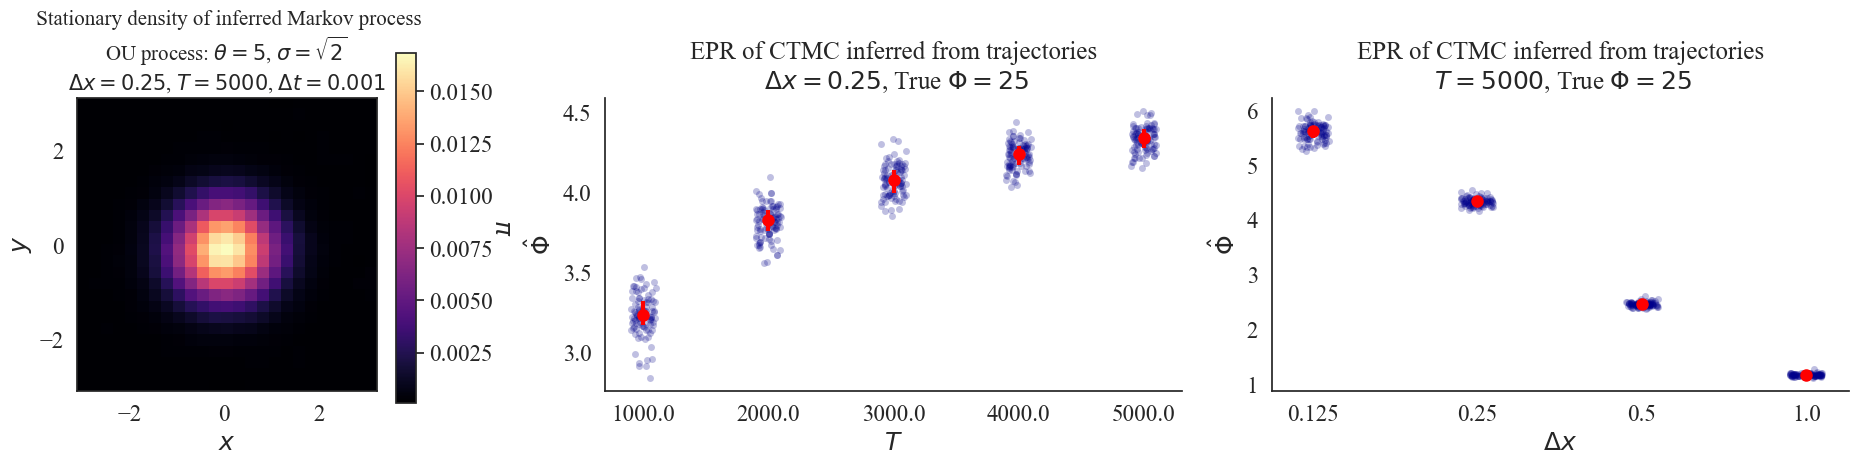

In [79]:
fig, ax = plt.subplots(1,3)
fig.set_size_inches(20,5)
im = ax[0].imshow(p_ss.reshape(num_cells_x,num_cells_y),origin = 'lower', extent = [xmin, xmax ,ymin, ymax],cmap = 'magma')
ax[0].set_aspect('equal')
cbar_ax = fig.add_axes([0.26, 0.16, 0.01, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'$\pi$', rotation=270, labelpad=15)

ax[0].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$y$')

ax[0].set_xlim([xmin,xmax])
ax[0].set_ylim([ymin,ymax])
ax[0].set_title(f' Stationary density of inferred Markov process\n' + r'OU process: $\theta = 5$, $\sigma = \sqrt{2}$' + f'\n' + r'$\Delta x = 0.25$, $T = 5000$, $\Delta t = 0.001$',fontsize = 15)

sample_lengths = list(0.001*np.array([1000000,2000000,3000000,4000000,5000000]))

EPR_byTime = np.array(pd.read_csv('EPR_byTime.csv',header=None))
df = pd.DataFrame(EPR_byTime, columns=[sample_lengths[i] for i in range(EPR_byTime.shape[1])])
df_melted = df.melt(var_name='Length', value_name='EPR')

sns.stripplot(x='Length', y='EPR', data=df_melted, jitter=True, alpha=0.25, color='darkblue',ax = ax[1])
ax[1].set_ylabel(r'$\hat{\Phi}$')
ax[1].set_xlabel(r'$T$')

for i, var in enumerate(df.columns):
    col_data = df[var]
    median = np.median(col_data)
    q1 = np.percentile(col_data, 25)
    q3 = np.percentile(col_data, 75)

    ax[1].plot(i, median, marker='o', color='red', markersize=8, zorder=10)

    ax[1].vlines(i, q1, q3, color='red', linewidth=3, zorder=9)
ax[1].set_title(f"EPR of CTMC inferred from trajectories\n" + r' $\Delta x = 0.25$, True $\Phi = 25$')
sns.despine(ax=ax[1])

dx_list = [1,0.5,0.25,0.125]
EPR_byDx = np.array(pd.read_csv('EPR_byDx.csv',header=None))
df = pd.DataFrame(EPR_byDx, columns=[dx_list[i] for i in range(EPR_byDx.shape[1])])
df_melted = df.melt(var_name='Grid-size', value_name='EPR')
sns.stripplot(x='Grid-size', y='EPR', data=df_melted, jitter=True, alpha=0.25, color='darkblue',ax = ax[2])

ax[2].set_ylabel(r'$\hat{\Phi}$')
ax[2].set_xlabel(r'$\Delta x$')

for i, var in enumerate(df.columns):
    col_data = df[var]
    median = np.median(col_data)
    q1 = np.percentile(col_data, 25)
    q3 = np.percentile(col_data, 75)

    ax[2].plot(3-i, median.T, marker='o', color='red', markersize=8, zorder=10)

    ax[2].vlines(3-i, q1, q3, color='red', linewidth=3, zorder=9)
ax[2].set_title(f"EPR of CTMC inferred from trajectories\n" + r' $T = 5000$, True $\Phi = 25$')
sns.despine(ax=ax[2])


plt.tight_layout()
plt.savefig("OUEPR_MLE.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [16]:
x0 = np.array([-2,1])
samples = 2000000
tau = 0.001
T= samples*tau

theta = 5; sigma = np.sqrt(2)
X = h.strang_splitting_planar_cycle_theta(theta,(sigma**2)/2,tau,samples,x0)

In [17]:
dx = 0.25
time_course,out_of_domain,counts,states_idx, grid_x, grid_y, no_states, num_cells_x, num_cells_y, xmin, xmax, ymin, ymax = h.coarse_grain_trajectory(X,dx,dy=dx)

In [18]:
L_init = h.bayesian_transition_initial(no_states, states_idx)
L_hat = h.CT_Markov_Chain_MLE(time_course, states_idx , L_init, no_states, dt = tau, out_of_domain= out_of_domain)
p_ss = h.sparse_stationary(L_hat)

ValueError: cannot reshape array of size 6400 into shape (23,23)

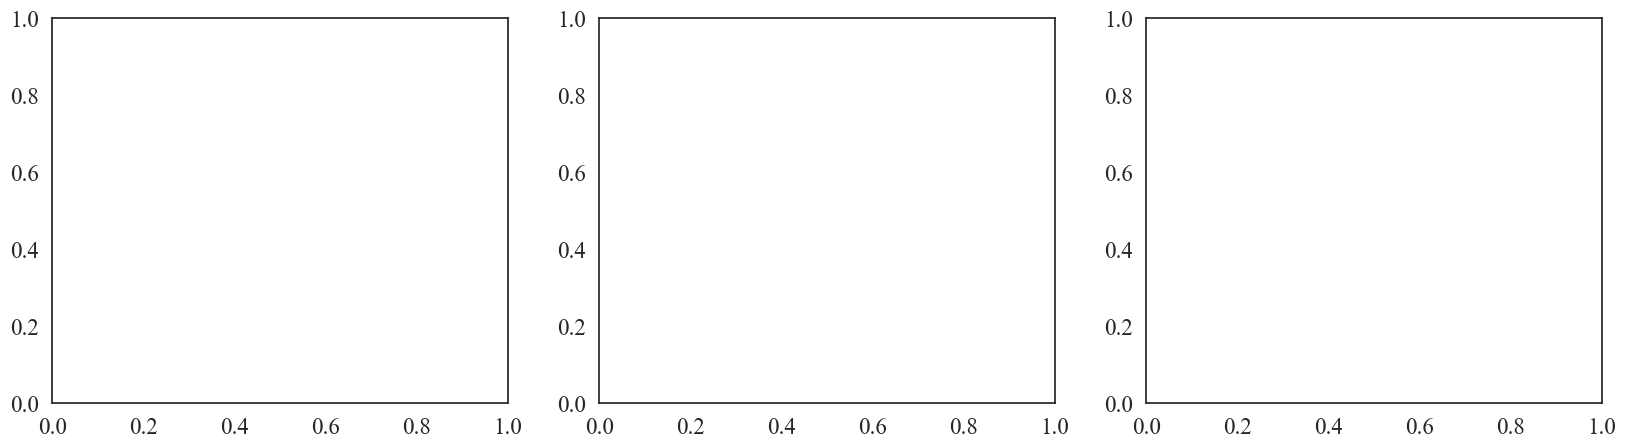

In [70]:
fig, ax = plt.subplots(1,3)
fig.set_size_inches(20,5)
im = ax[0].imshow(p_ss.reshape(num_cells_x,num_cells_y),origin = 'lower', extent = [xmin, xmax ,ymin, ymax],cmap = 'magma')
ax[0].set_aspect('equal')
cbar_ax = fig.add_axes([0.26, 0.16, 0.01, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'$\pi$', rotation=270, labelpad=15)

ax[0].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$y$')

ax[0].set_xlim([xmin,xmax])
ax[0].set_ylim([ymin,ymax])
ax[0].set_title(f' Stationary density of inferred Markov process\n' + r'Hopf oscillator: $\theta = 5$, $\sigma = \sqrt{2}$' + f'\n' + r'$\Delta x = 0.25$, $T = 2000$, $\Delta t = 0.001$',fontsize = 15)

sample_lengths = list(0.001*np.array([1000000,2000000,3000000,4000000,5000000]))

EPR_byTime = np.array(pd.read_csv('EPR_byTimePLC.csv',header=None))
df = pd.DataFrame(EPR_byTime, columns=[sample_lengths[i] for i in range(EPR_byTime.shape[1])])
df_melted = df.melt(var_name='Length', value_name='EPR')

sns.stripplot(x='Length', y='EPR', data=df_melted, jitter=True, alpha=0.25, color='darkblue',ax = ax[1])
ax[1].set_ylabel(r'$\hat{\Phi}$')
ax[1].set_xlabel(r'$T$')

for i, var in enumerate(df.columns):
    col_data = df[var]
    median = np.median(col_data)
    q1 = np.percentile(col_data, 25)
    q3 = np.percentile(col_data, 75)

    ax[1].plot(i, median, marker='o', color='red', markersize=8, zorder=10)

    ax[1].vlines(i, q1, q3, color='red', linewidth=3, zorder=9)
ax[1].set_title(f"EPR of CTMC inferred from trajectories\n" + r' $\Delta x = 0.25$, True $\Phi = 39.45$')
sns.despine(ax=ax[1])

dx_list = [1,0.5,0.25,0.125]
EPR_byDx = np.array(pd.read_csv('EPR_byDxPLC.csv',header=None))
df = pd.DataFrame(EPR_byDx, columns=[dx_list[i] for i in range(EPR_byDx.shape[1])])
df_melted = df.melt(var_name='Grid-size', value_name='EPR')
sns.stripplot(x='Grid-size', y='EPR', data=df_melted, jitter=True, alpha=0.25, color='darkblue',ax = ax[2])

ax[2].set_ylabel(r'$\hat{\Phi}$')
ax[2].set_xlabel(r'$\Delta x$')

for i, var in enumerate(df.columns):
    col_data = df[var]
    median = np.median(col_data)
    q1 = np.percentile(col_data, 25)
    q3 = np.percentile(col_data, 75)

    ax[2].plot(3-i, median.T, marker='o', color='red', markersize=8, zorder=10)

    ax[2].vlines(3-i, q1, q3, color='red', linewidth=3, zorder=9)
ax[2].set_title(f"EPR of CTMC inferred from trajectories\n" + r' $T = 5000$, True $\Phi = 39.45$')
sns.despine(ax=ax[2])


plt.tight_layout()
plt.savefig("hopf_inference_fig.pdf", format="pdf", bbox_inches="tight")
plt.show()

We also consider the behaviour of the process as the time-step goes to zero.

In [27]:
taus = [0.5,0.01,0.05,0.01,0.005,0.001]

EPR_byTimestep = np.array(pd.read_csv('EPR_byTimestepPLC2.csv',header=None))
df = pd.DataFrame(EPR_byTimestep, columns=[taus[i] for i in range(EPR_byTimestep.shape[1])])
df_melted = df.melt(var_name='Time-step', value_name='EPR')
df_melted['Time-step'] = df_melted['Time-step'].astype(float)

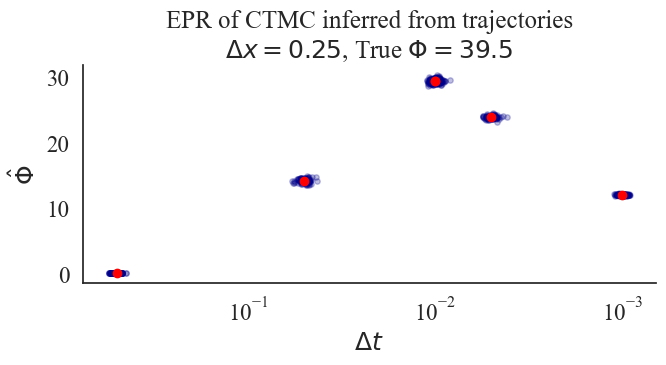

In [36]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(7,4)

rng = np.random.default_rng(0)
x = df_melted['Time-step'].values
y = df_melted['EPR'].values

x_jittered = x * np.exp(rng.normal(0, 0.05, size=len(x)))

ax.scatter(
    x_jittered,
    y,
    alpha=0.25,
    color='darkblue',
    s=15
)

ax.set_xscale('log')  
ax.invert_xaxis()      
ax.set_xlabel(r'$\Delta t$')
ax.set_ylabel(r'$\hat{\Phi}$')

ax.set_title(
    "EPR of CTMC inferred from trajectories\n"
    + r'$\Delta x = 0.25$, True $\Phi = 39.5$'
)

for tau in sorted(df.columns.astype(float)):
    col = df[tau]
    ax.plot(tau, np.median(col), 'o', color='red', zorder=10)
    ax.vlines(
        tau,
        np.percentile(col, 25),
        np.percentile(col, 75),
        color='red',
        linewidth=2,
        zorder=9
    )

sns.despine()
plt.tight_layout()
plt.savefig("EPR_byTimestep.pdf", format="pdf", bbox_inches="tight")
plt.show()

An alternative way to solve the embedding problem is to consider a nonconvex optimisation problem,

$$
L^*= \text{argmin}_{L\in \mathcal{L}}||P-\exp\left(L\Delta t\right)||_F,
$$

where we find the best fitting Laplacian with a given structure based on the transition matrix in discrete time. We show this procedure below.

In [7]:
x0 = np.array([-2,1])
samples = 5000000
tau = 0.01
T= samples*tau

theta = 5; sigma = np.sqrt(2)
X = h.OU_simulation(theta,sigma,x0,tau,samples)

dx = 0.25
time_course,out_of_domain,counts,states_idx, grid_x, grid_y, no_states, num_cells_x, num_cells_y, xmin, xmax, ymin, ymax = h.coarse_grain_trajectory(X,dx,dy=dx)

def transition_matrix_inference(states,N):
    P_hat = np.ones((N,N))
    for t in range(0, len(states)-1):
        source = states[t]
        sink = states[t+1]
        P_hat[sink,source] +=1
    column_sums = P_hat.sum(axis=0)
    P_hat = P_hat / column_sums
    return P_hat

P_hat = transition_matrix_inference(time_course, no_states)

In [8]:
def fit_ctmc_L_matrix(P_observed, mask, dt=1.0, max_iter=5000):
    
    n = P_observed.shape[0]
    
    rows, cols = np.where(mask & ~np.eye(n, dtype=bool))
    
    initial_params = np.ones(len(rows)) * 0.1
    
    def params_to_L(params):
        L = np.zeros((n, n))
        
        L[rows, cols] = params
        
        col_sums_off_diag = L.sum(axis=0)
        np.fill_diagonal(L, -col_sums_off_diag)
        return L

    pbar = tqdm(total=max_iter, desc="Optimising L", unit="eval")
    
    def objective(params):
        L = params_to_L(params)
        P_est = expm(L * dt)
        error = norm(P_observed - P_est)

        pbar.update(1)
        pbar.set_postfix({"Error": f"{error:.5f}"})
        
        return error 

    bounds = [(0, None) for _ in range(len(rows))]

    result = minimize(
        objective, 
        initial_params, 
        method='L-BFGS-B', 
        bounds=bounds,
        options={'ftol': 1e-9}
    )
    
    return params_to_L(result.x), result.fun

In [ ]:
L_init = h.bayesian_transition_initial(no_states, states_idx)
mask_bool = L_init.astype(bool)
L_est, error = fit_ctmc_L_matrix(P_hat, mask_bool, tau)
L_hat = h.CT_Markov_Chain_MLE(time_course, states_idx , L_init, no_states, dt = tau, out_of_domain= out_of_domain)

Optimizing L:  93%|█████████████████████████████████████████████████████████████████████▏    | 4672/5000 [01:35<00:06, 50.07eval/s, Error=26.96178]

In [ ]:
p_ss_mle = h.sparse_stationary(L_hat)
p_ss_opt = h.sparse_stationary(L_est)

x = np.linspace(xmin, xmax, 5001)
y = np.linspace(ymin, ymax, 5001)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
rv = multivariate_normal([0,0], 0.25*(sigma**2)*np.eye(2))
Z = rv.pdf(pos)
Z_scaled = np.sum(p_ss_mle)*Z/np.sum(Z)

fig, ax = plt.subplots(1,3)
fig.set_size_inches(15,5)
im = ax[0].imshow(p_ss_mle.reshape(num_cells_x,num_cells_y),origin = 'lower', extent = [xmin, xmax ,ymin, ymax],cmap = 'magma')

im = ax[1].imshow(p_ss_opt.reshape(num_cells_x,num_cells_y),origin = 'lower', extent = [xmin, xmax ,ymin, ymax],cmap = 'magma')

im = ax[2].imshow(Z_scaled,origin = 'lower', extent = [xmin, xmax ,ymin, ymax],cmap = 'magma')

for a in ax:
    a.set_xticks([-2,0,2])
    a.set_yticks([-2,0,2])

ax[0].set_title(r'MLE')
ax[1].set_title(r'Optimisation approach')
ax[2].set_title(r'Exact density')
ax[0].set_ylabel('Ornstein-Uhlenbeck')

plt.tight_layout()

plt.show()

## Non-diagonal diffusion

We take an OU process of the form
$$
B = \begin{pmatrix}
        2 & -1\\
        1 & 2
    \end{pmatrix},
$$

$$
 D =\begin{pmatrix} 
        4 & 1\\
        1 & 2
    \end{pmatrix},
$$
and adjust our method to account for the non-diagonal diffusion, as in the paper.

In [ ]:
B =  np.array([[2, -1],[1, 2]])
D = np.array([[4, 1],[1, 2]])

Lambda, V = np.linalg.eig(D)
V_inv = np.linalg.inv(V)
l1 = Lambda[0]; l2 = Lambda[1]
v1 = V[:,0]
v2 = V[:,1]

B_rot = V_inv @ B @ V

def f_x(x,y):
    z = -B_rot@np.array([x,y])
    return z[0]

def f_y(x,y):
    z = -B_rot@np.array([x,y])
    return z[1]

def D_xx(x,y):
    return l1

def D_yy(x,y):
    return l2

xmin = -10; xmax = 10;
ymin = -10; ymax = 10;
dx = 0.5; dy = 0.5;

L, x_midpoints, y_midpoints, x_left, x_right, y_left, y_right = h.SG_2d_reflecting_boundaries(
        [f_x, f_y], [D_xx, D_yy], dx, xmin, xmax, dx, ymin, ymax
    )

p_ss = h.efficient_stationary_dist(L).reshape(x_midpoints.shape[0], y_midpoints.shape[0]) / (dx**2)

Nx = x_midpoints.size
Ny = y_midpoints.size

polygons = []
colors = []

half_dx = dx * 0.5
half_dy = dy * 0.5


for i in range(Nx):
    cx = x_midpoints[i]
    for j in range(Ny):
        cy = y_midpoints[j]
        corners_rot = np.array([
            [cx - half_dx, cy - half_dy],
            [cx + half_dx, cy - half_dy],
            [cx + half_dx, cy + half_dy],
            [cx - half_dx, cy + half_dy],
        ])  # shape (4,2)

        corners_orig = (V @ corners_rot.T).T
        polygons.append(corners_orig)
        colors.append(p_ss[i, j])   

pc = PolyCollection(polygons, array=np.array(colors), cmap='magma', edgecolors='none')

S = la.solve_sylvester(B, B.T, 2*D)
x = np.linspace(xmin, xmax, 1000)
y = np.linspace(ymin, ymax, 1000)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
rv = multivariate_normal([0,0], S)
Z = rv.pdf(pos)
Z_scaled = np.sum(p_ss)*Z/np.sum(Z)

In [ ]:
cmap = 'magma'
fig, ax = plt.subplots(1,3)
fig.set_size_inches(12,4)

im = ax[0].imshow(p_ss, extent=[xmin, xmax, ymin, ymax], 
                      origin='lower', cmap=cmap)

ax[0].set_xlabel(r'$\nu$')
ax[0].set_ylabel(r'$\eta$')
ax[0].set_title('Transformed Space')
ax[0].set_aspect('equal')

ax[1].set_title('Original Space')
pc = PolyCollection(polygons, array=np.array(colors), cmap='magma', edgecolors='none')
ax[1].add_collection(pc)

all_xy = np.vstack(polygons)
xmin, ymin = all_xy.min(axis=0)
xmax, ymax = all_xy.max(axis=0)
ax[1].set_xlim(xmin - 0.02*(xmax-xmin), xmax + 0.02*(xmax-xmin))
ax[1].set_ylim(ymin - 0.02*(ymax-ymin), ymax + 0.02*(ymax-ymin))

ax[1].set_aspect('equal')
ax[1].set_xlabel(r'$x$')
ax[1].set_ylabel(r'$y$')

ax[2].set_title('Exact Density')
ax[2].set_xlabel(r'$x$')
ax[2].set_ylabel(r'$y$')
c = ax[2].contourf(X, Y, Z, levels=100, cmap=cmap,vmin=vmin,vmax=vmax)
ax[2].set_aspect('equal')

plt.tight_layout()
plt.show()